# ESS 배터리 수명 예측을 위한 EDA 및 모델 설계

Stanford & MIT 공개 배터리 실험 데이터의 **Batch 1·2·3**을 분석합니다. 기존 `01_EDA.ipynb`의 데이터 확인 → EDA → 모델 설계 흐름을 확장했습니다.

**분석 목적:** 초기 100사이클의 신호가 총수명과 어떻게 연결되는지 확인하고, ESS 운영·유지보수 담당자가 초기 데이터를 바탕으로 점검 우선순위와 교체 계획을 검토할 수 있도록 모델을 설계합니다. 초기 셀 평가를 운영 의사결정과 연결하는 분석이며, 실제 적용 효과는 현장 데이터로 확인하는 항목입니다.

원본 데이터에서 다섯 EDA 질문을 분석하고, 배치별 관찰과 비교 결과를 **피처 정의·후보 모델 선정·전처리와 검증 기준**으로 연결합니다.

### 실습 방법
1. 각 질문의 **원래 질문 / 구체화한 질문**을 읽습니다.
2. 질문 아래의 **실습 설정**에서 임계값·분석 대상을 수정할 수 있습니다.
3. 설정을 수정하면 해당 질문부터 아래 셀을 순서대로 다시 실행합니다. 데이터 경로나 공통 품질 기준을 바꾸면 전체 셀을 다시 실행합니다.
4. 표와 그래프를 확인한 뒤 **관찰 → 해석 → 모델 설계 근거**를 수정합니다. 표시된 해석은 현재 기본 설정으로 실행한 결과입니다.

**그래프 구성:** 모든 그림은 한 배치의 데이터만 포함합니다. Batch 1→2→3 개별 그래프와 해석 뒤에 배치 비교·모델 설계 근거를 제시합니다. 수명·열화·ΔQ·충전 관계 그래프의 동일 지표에는 공통 축 범위를 적용했습니다.

**분석의 관점:** 배치별 그래프를 읽은 뒤 수명 분포·열화 형태·초기 신호의 차이를 모델의 입력·검증·적용 범위로 연결한다. 특히 QD2의 높은 통합 상관이 배치 내 관계를 뜻하는지 구분하고, ΔQ 변화량과 전류 피처의 추가 가치를 검증 대상으로 정한다.

개발·평가 결과로 이어지는 해석은 `03_modeling.ipynb`의 「시사점의 근거와 의사결정 기준」, 전체 결론은 `../docs/insights.md`에서 확인한다.

## 분석 환경 설정

Python 3.11 이상에서 `requirements.txt`의 패키지를 설치하고 해당 환경의 Python 커널을 선택합니다.
프로젝트 루트 또는 `notebooks/`에서 실행하면 프로젝트 폴더를 자동으로 찾습니다.
원본 MAT의 기본 위치는 `data/raw/`이며, 다른 위치는 `ESS_DATA_DIR`로 지정합니다.
출력은 프로젝트의 `results/eda/`에 저장되고 `ESS_EDA_OUT`으로 변경할 수 있습니다.

세 파일은 MATLAB v7.3(HDF5) 형식입니다. `h5py`로 필요한 요약과 초기 곡선·전류 파형을 읽어
전체 시계열을 한 번에 메모리에 올리지 않습니다. 모델 입력의 관측 범위는 실제 사이클 2–100입니다.


In [1]:
%matplotlib inline
from pathlib import Path
import os, re, json, sys, importlib.metadata
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110,
                     "font.family": "DejaVu Sans", "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
BLUE, GOLD, GRAY = "#275E78", "#A46E25", "#66717B"
print("Python:", sys.version.split()[0])
print({p: importlib.metadata.version(p) for p in ["numpy", "pandas", "h5py", "scipy", "matplotlib"]})

Matplotlib is building the font cache; this may take a moment.


Python: 3.11.15
{'numpy': '2.4.6', 'pandas': '3.0.6', 'h5py': '3.16.0', 'scipy': '1.17.1', 'matplotlib': '3.11.2'}


### 데이터 경로와 공통 실습 설정

기본 원본 폴더는 프로젝트의 `data/raw/`입니다. 기존 실습의 `archive/`도 인식하며, 다른 위치는 `ESS_DATA_DIR`로 지정합니다. 분석 대상은 `BATCH_FILES`에 정의한 세 배치 MAT 파일입니다.

- EOL 참조 용량: 공칭 1.1Ah × 80% = 0.88Ah.
- 비정상 QD 행: 비유한·비양수·1.5Ah 이상. 정상적인 EOL 이하 용량은 보존합니다.
- EOL 근처 종료 집단: 마지막 유효 QD 5개 중앙값≤0.885Ah인 셀. 정확한 EOL 관측 확정과 구분합니다.

In [2]:
# 실습 설정: 경로/품질 기준을 변경하면 전체 셀을 다시 실행하세요.
# 프로젝트 루트는 현재 폴더 또는 부모 폴더에서 찾습니다.
project_override = os.environ.get('ESS_PROJECT_DIR') or os.environ.get('ESS_DAY2_PROJECT')
project_choices = ([Path(project_override).expanduser()] if project_override else
                   [Path.cwd(), Path.cwd() / 'day2_project',
                    Path.cwd().parent, Path.cwd().parent / 'day2_project'])
PROJECT_DIR = next((p.resolve() for p in project_choices
                    if (p / 'src/train.py').is_file()
                    and (p / 'data/processed/cells_and_features.csv').is_file()), None)
if PROJECT_DIR is None:
    raise FileNotFoundError('프로젝트 루트에서 실행하거나 ESS_PROJECT_DIR로 프로젝트 폴더를 지정하세요.')
# 기본 원본 폴더는 data/raw이며, 기존 실습의 archive 폴더도 인식합니다.
raw_choices = [PROJECT_DIR / 'data/raw', PROJECT_DIR / 'archive', PROJECT_DIR.parent / 'archive']
default_raw_dir = next((p for p in raw_choices
                        if (p / '2017-05-12_batchdata_updated_struct_errorcorrect.mat').is_file()),
                       PROJECT_DIR / 'data/raw')
DATA_DIR = Path(os.environ.get('ESS_DATA_DIR', str(default_raw_dir))).expanduser().resolve()
OUT = Path(os.environ.get('ESS_EDA_OUT', str(PROJECT_DIR / 'results/eda'))).expanduser().resolve()
OUT.mkdir(parents=True, exist_ok=True)
(OUT / "charts").mkdir(exist_ok=True)
BATCH_FILES = {
    1: "2017-05-12_batchdata_updated_struct_errorcorrect.mat",
    2: "2018-02-20_batchdata_updated_struct_errorcorrect.mat",
    3: "2018-04-12_batchdata_updated_struct_errorcorrect.mat",
}
NOMINAL_AH, EOL_FRACTION = 1.1, 0.8
EOL_AH = NOMINAL_AH * EOL_FRACTION
QD_UPPER_AH = 1.5
EOL_NEAR_AH = 0.885
EARLY_START, EARLY_END = 2, 100
SEED = 42
np.random.seed(SEED)

for b, name in BATCH_FILES.items():
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Batch {b} 원본 파일을 찾을 수 없습니다: {path}")
    if not h5py.is_hdf5(path):
        raise ValueError(f"HDF5 형식이 아닙니다: {path}")
    print(f"Batch {b}: {name} ({path.stat().st_size / 2**30:.2f} GiB)")

def show_and_save(name):
    plt.tight_layout()
    plt.savefig(OUT / "charts" / f"{name}.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

Batch 1: 2017-05-12_batchdata_updated_struct_errorcorrect.mat (2.82 GiB)
Batch 2: 2018-02-20_batchdata_updated_struct_errorcorrect.mat (1.88 GiB)
Batch 3: 2018-04-12_batchdata_updated_struct_errorcorrect.mat (3.01 GiB)


## 데이터 구조 및 사이클 식별 검토

HDF5의 `batch`는 셀별 데이터에 대한 참조를 보관합니다. `summary`에는 사이클 요약, `cycles`에는 전압·전류와 Qdlin 등의 배열이 있습니다. 아래 셀에서 구조를 직접 확인합니다.

In [3]:
with h5py.File(DATA_DIR / BATCH_FILES[1], "r") as handle:
    batch = handle["batch"]
    first_summary = handle[batch["summary"][0, 0]]
    first_cycles = handle[batch["cycles"][0, 0]]
    print("Batch 1 셀 수:", batch["summary"].shape[0])
    print("batch 필드:", list(batch))
    print("summary 필드:", list(first_summary))
    print("cycles 필드:", list(first_cycles))
    print("실제 cycle 라벨 앞부분:", np.asarray(first_summary["cycle"][()]).reshape(-1)[:12])

Batch 1 셀 수: 46
batch 필드: ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
summary 필드: ['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']
cycles 필드: ['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
실제 cycle 라벨 앞부분: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12.]


### 사이클 요약 및 초기 방전 곡선 추출

배치 번호를 포함한 `b1c0` 형태의 ID로 셀을 구분합니다. cycle 번호는 원본 `summary['cycle']`을 사용합니다. 타깃 결측을 `int()`로 변환하거나 추정해 채우지 않습니다. Qdlin 배열 위치는 실제 cycle 라벨에서 찾습니다.

In [4]:
def vector(dataset):
    return np.asarray(dataset[()], dtype=float).reshape(-1)

def decode_text(dataset):
    return "".join(chr(int(v)) for v in dataset[()].reshape(-1))

def read_batch(batch_no, path):
    """원본 summary와 필요한 초기 곡선만 읽습니다. 원본에는 쓰지 않습니다."""
    cell_rows, summary_frames, curves = [], [], {}
    with h5py.File(path, "r") as handle:
        batch = handle["batch"]
        for index in range(batch["summary"].shape[0]):
            cell_id = f"b{batch_no}c{index}"
            summary_group = handle[batch["summary"][index, 0]]
            curve_group = handle[batch["cycles"][index, 0]]
            summary = {k: vector(summary_group[k]) for k in
                       ["cycle", "QDischarge", "QCharge", "IR", "Tavg", "Tmax", "Tmin", "chargetime"]}
            if len({len(v) for v in summary.values()}) != 1:
                raise ValueError(f"요약 배열 길이 불일치: {cell_id}")
            cycle = summary["cycle"]
            if not np.all(np.diff(cycle) > 0):
                raise ValueError(f"cycle 라벨 순서/중복 확인 필요: {cell_id}")
            life = float(vector(handle[batch["cycle_life"][index, 0]])[0])
            policy = decode_text(handle[batch["policy_readable"][index, 0]])
            qd = summary["QDischarge"]
            usable = (cycle >= 2) & np.isfinite(qd) & (qd > 0) & (qd < QD_UPPER_AH)
            tail = qd[usable][-5:]
            cell_rows.append({
                "cell_id": cell_id, "batch": batch_no, "cell_index": index,
                "cycle_life": life, "charging_policy": policy,
                "summary_cycles": len(cycle),
                "QD_bad_rows": int((~np.isfinite(qd) | (qd <= 0) | (qd >= QD_UPPER_AH)).sum()),
                "tail_median_QD": float(np.median(tail)) if len(tail) else np.nan,
                "eol_near": bool(len(tail) and np.median(tail) <= EOL_NEAR_AH),
            })
            frame = pd.DataFrame(summary).rename(columns={"QDischarge": "QD", "QCharge": "QC"})
            frame["cell_id"], frame["batch"], frame["cycle_life"] = cell_id, batch_no, life
            summary_frames.append(frame)
            voltage = vector(handle[batch["Vdlin"][index, 0]])
            q_curves = {}
            for actual_cycle in [10, 100]:
                matches = np.flatnonzero(cycle == actual_cycle)
                if len(matches) != 1:
                    raise ValueError(f"cycle {actual_cycle} 라벨 확인 필요: {cell_id}")
                q_curves[actual_cycle] = vector(handle[curve_group["Qdlin"][int(matches[0]), 0]])
            if not all(len(q) == len(voltage) for q in q_curves.values()):
                raise ValueError(f"전압과 Qdlin 길이 불일치: {cell_id}")
            order = np.argsort(voltage)
            if not np.all(np.diff(voltage[order]) > 0):
                raise ValueError(f"전압 축 중복 확인 필요: {cell_id}")
            curves[cell_id] = {"V": voltage[order], "Q10": q_curves[10][order], "Q100": q_curves[100][order]}
    return pd.DataFrame(cell_rows), pd.concat(summary_frames, ignore_index=True), curves

In [5]:
cell_parts, summary_parts, curve_records, provenance = [], [], {}, []
for batch_no, name in BATCH_FILES.items():
    path = DATA_DIR / name
    batch_cells, batch_summary, batch_curves = read_batch(batch_no, path)
    cell_parts.append(batch_cells)
    summary_parts.append(batch_summary)
    curve_records.update(batch_curves)
    provenance.append({"batch": batch_no, "file": name, "bytes": path.stat().st_size,
                       "raw_cells": len(batch_cells)})
    print(f"Batch {batch_no}: {len(batch_cells)}셀, {len(batch_summary):,}사이클 행 로딩 완료")
cells = pd.concat(cell_parts, ignore_index=True)
df = pd.concat(summary_parts, ignore_index=True)
assert cells.cell_id.is_unique
assert not df.duplicated(["cell_id", "cycle"]).any()
valid_targets = cells.dropna(subset=["cycle_life"]).copy()
eol_targets = valid_targets[valid_targets.eol_near].copy()
display(cells.head(3))
display(df.head(3))

Batch 1: 46셀, 38,811사이클 행 로딩 완료


Batch 2: 47셀, 26,904사이클 행 로딩 완료


Batch 3: 46셀, 51,007사이클 행 로딩 완료


,cell_id,batch,cell_index,cycle_life,charging_policy,summary_cycles,QD_bad_rows,tail_median_QD,eol_near
0,b1c0,1,0,1190.0,3.6C(80%)-3.6C,1189,2,1.026499,False
1,b1c1,1,1,1179.0,3.6C(80%)-3.6C,1178,1,1.038700,False
2,b1c2,1,2,1177.0,3.6C(80%)-3.6C,1176,1,1.043586,False


,cycle,QD,QC,IR,Tavg,Tmax,Tmin,chargetime,cell_id,batch,cycle_life
0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,b1c0,1,1190.0
1,2.0,1.070689,1.071042,0.016742,31.875011,35.652016,29.566130,13.341250,b1c0,1,1190.0
2,3.0,1.071900,1.071674,0.016724,31.931490,35.692978,29.604385,13.425777,b1c0,1,1190.0


### 분석 단위 및 데이터 품질 검토

수명 분포는 **셀당 한 행**, 열화 곡선은 **셀별 사이클 행**입니다. 두 분모를 섞지 않습니다. EOL 근처 집단은 라벨 완전성을 비교하기 위한 하위집단이며, 더 큰 상관을 얻기 위해 선택하는 집단이 아닙니다.

In [6]:
quality = cells.groupby("batch").agg(
    raw_cells=("cell_id", "size"), valid_targets=("cycle_life", "count"),
    QD_bad_rows=("QD_bad_rows", "sum"), eol_near_raw=("eol_near", "sum"),
)
quality["missing_targets"] = quality.raw_cells - quality.valid_targets
quality["eol_near_targets"] = eol_targets.groupby("batch").size()
display(quality)
print("셀/사이클 중복:", df.duplicated(["cell_id", "cycle"]).sum())
print("전압 축:", min(v["V"].min() for v in curve_records.values()),
      "~", max(v["V"].max() for v in curve_records.values()), "V")

,raw_cells,valid_targets,QD_bad_rows,eol_near_raw,missing_targets,eol_near_targets
batch,,,,,,
1,46,46,48,33,0,33
2,47,39,11,43,8,39
3,46,44,0,44,2,44


셀/사이클 중복: 0
전압 축: 2.0 ~ 3.5 V


## 1. 배치별 수명 분포 분석

**원래 질문:** 수명 분포는 어떻게 생겼는가?

**구체화한 질문:** 세 배치의 수명 범위와 장·단수명 비중은 어떻게 다른가? 짧은 셀은 배치 내 통계적 이상치인가? Batch 1로 개발할 때 어떤 타깃 범위를 충분히 배우기 어려운가?

최단 수명 셀의 식별 결과는 5절의 **최단 수명 셀 통합 진단**에서 초기 용량·ΔQ·저항·온도·실제 전류 및 동일 정책 셀과 연결해 검토합니다.

In [7]:
# 실습 설정: 탐색 기준과 분류 기준을 구분합니다.
SHORT_LIFE, LONG_LIFE = 500, 1000
CLASSIFICATION_CUTOFF = 550
HIST_MIN, HIST_MAX, HIST_BIN_WIDTH = 150, 2300, 150

def summarize_lifetimes(data):
    rows = []
    for batch_no, group in data.groupby("batch"):
        life = group.cycle_life.dropna()
        q1, q3 = life.quantile([.25, .75])
        lower, upper = q1 - 1.5*(q3-q1), q3 + 1.5*(q3-q1)
        rows.append({"batch": batch_no, "n": len(life), "mean": life.mean(), "median": life.median(),
                     "min": life.min(), "max": life.max(), "Q1": q1, "Q3": q3,
                     "short_n": int((life < SHORT_LIFE).sum()), "short_pct": 100*(life < SHORT_LIFE).mean(),
                     "long_n": int((life > LONG_LIFE).sum()), "long_pct": 100*(life > LONG_LIFE).mean(),
                     "below_class_cutoff": int((life < CLASSIFICATION_CUTOFF).sum()),
                     "iqr_lower": lower, "iqr_upper": upper,
                     "iqr_outliers": int(((life < lower) | (life > upper)).sum())})
    return pd.DataFrame(rows)
life_profile = summarize_lifetimes(valid_targets)
display(life_profile.round(2))

,batch,n,mean,median,min,max,Q1,Q3,short_n,short_pct,long_n,long_pct,below_class_cutoff,iqr_lower,iqr_upper,iqr_outliers
0,1,46,844.72,858.5,534.0,1227.0,703.25,914.25,0,0.00,10,21.74,1,386.75,1230.75,0
1,2,39,565.74,472.0,392.0,1186.0,439.50,508.50,28,71.79,3,7.69,30,336.00,612.00,9
2,3,44,1059.66,1005.5,541.0,1935.0,828.00,1155.25,0,0.00,23,52.27,1,337.12,1646.12,3


In [8]:
# 모든 배치에 같은 bin·축 범위를 적용합니다.
def plot_lifetime(batch_no):
    group=valid_targets[valid_targets.batch==batch_no]
    edges=np.arange(HIST_MIN,HIST_MAX+HIST_BIN_WIDTH,HIST_BIN_WIDTH)
    ymax=max(np.histogram(g.cycle_life,bins=edges)[0].max() for _,g in valid_targets.groupby('batch'))+2
    fig,ax=plt.subplots(figsize=(9,3.3))
    ax.hist(group.cycle_life,bins=edges,color=BLUE,edgecolor='white',label='All valid targets')
    ax.hist(group.loc[~group.eol_near,'cycle_life'],bins=edges,histtype='step',color='black',label='EOL-near unconfirmed')
    ax.axvline(SHORT_LIFE,color=GRAY,linestyle=':',label=f'Short <{SHORT_LIFE}')
    ax.axvline(LONG_LIFE,color=GRAY,linestyle='--',label=f'Long >{LONG_LIFE}')
    ax.set(title=f'Batch {batch_no} Cycle Life Distribution | n={len(group)}',xlabel='Recorded life (cycles)',ylabel='Cells',xlim=(HIST_MIN,HIST_MAX),ylim=(0,ymax))
    ax.legend(fontsize=8)
    show_and_save(f'q1_lifetime_b{batch_no}')
    r=life_profile[life_profile.batch==batch_no].iloc[0]
    display(Markdown(f'**Batch {batch_no} 관찰:** 유효 타깃 {int(r.n)}셀, 중앙값 {r["median"]:.1f}사이클, 범위 {r["min"]:.0f}~{r["max"]:.0f}. 단수명 {int(r.short_n)}셀({r.short_pct:.1f}%), 장수명 {int(r.long_n)}셀({r.long_pct:.1f}%).'))

### 수명 분포 분석 · Batch 1

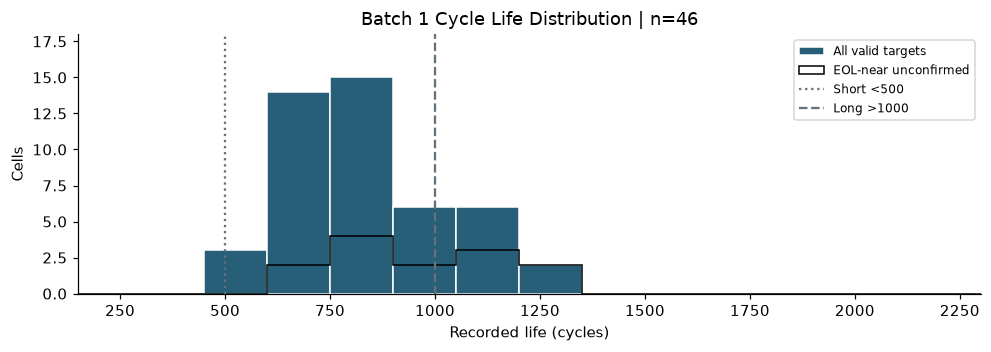

**Batch 1 관찰:** 유효 타깃 46셀, 중앙값 858.5사이클, 범위 534~1227. 단수명 0셀(0.0%), 장수명 10셀(21.7%).

In [9]:
plot_lifetime(1)

Batch 1의 기록 수명은 중간 구간에 집중됩니다. 검은 윤곽선은 EOL 근처 종료가 확인되지 않은 기록이므로 라벨 이력을 함께 봅니다.

### 수명 분포 분석 · Batch 2

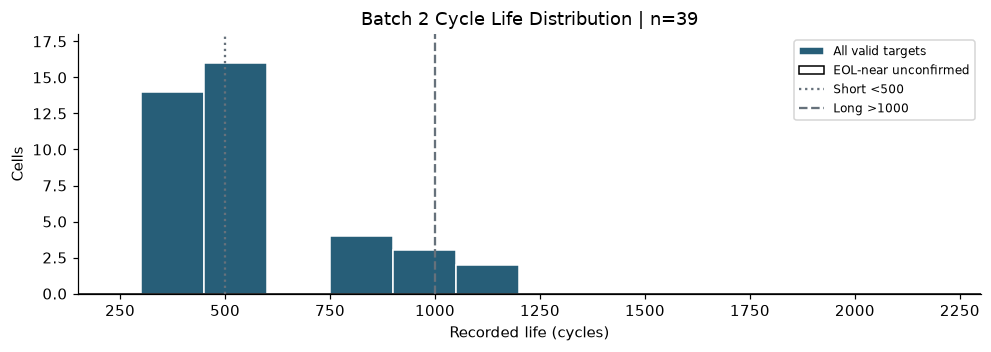

**Batch 2 관찰:** 유효 타깃 39셀, 중앙값 472.0사이클, 범위 392~1186. 단수명 28셀(71.8%), 장수명 3셀(7.7%).

In [10]:
plot_lifetime(2)

Batch 2에는 짧은 수명과 일부 긴 수명이 함께 존재합니다. 평균만으로 대표하면 긴 수명 꼬리의 영향을 받습니다.

### 수명 분포 분석 · Batch 3

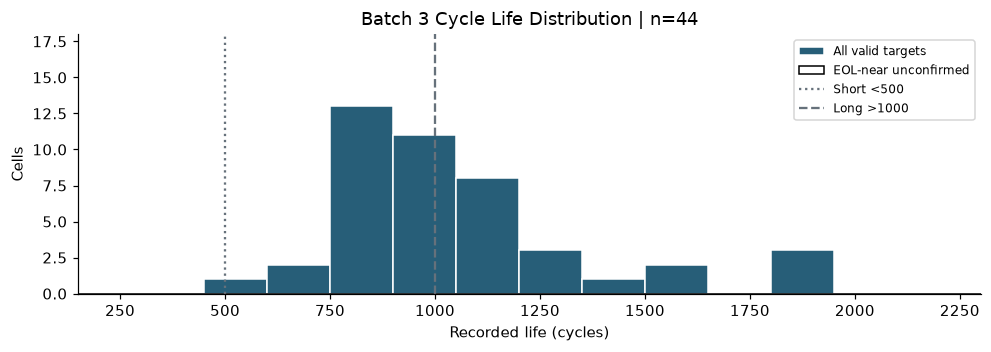

**Batch 3 관찰:** 유효 타깃 44셀, 중앙값 1005.5사이클, 범위 541~1935. 단수명 0셀(0.0%), 장수명 23셀(52.3%).

In [11]:
plot_lifetime(3)

Batch 3은 긴 수명의 범위가 넓습니다. 배치 차이의 원인을 특정 운전 조건의 효과로 단정하지 않습니다.

In [12]:
shortest = valid_targets.loc[valid_targets.groupby("batch").cycle_life.idxmin()].copy()
shortest = shortest.merge(life_profile[["batch", "iqr_lower", "iqr_upper"]], on="batch", validate="one_to_one")
shortest["is_IQR_outlier"] = (shortest.cycle_life < shortest.iqr_lower) | (shortest.cycle_life > shortest.iqr_upper)
display(shortest[["batch", "cell_id", "cycle_life", "charging_policy", "tail_median_QD", "is_IQR_outlier"]])

,batch,cell_id,cycle_life,charging_policy,tail_median_QD,is_IQR_outlier
0,1,b1c20,534.0,5.4C(80%)-5.4C,0.883584,False
1,2,b2c19,392.0,6C(60%)-3C,0.832406,False
2,3,b3c28,541.0,3.7C(31%)-5.9C-newstructure,0.881752,False


In [13]:
# IQR 삭제가 예측 대상의 수명 범위를 바꾸는지 확인합니다. 삭제는 수행하지 않습니다.
iqr_rows=[]
for batch_no,group in valid_targets.groupby('batch'):
    profile=life_profile[life_profile.batch==batch_no].iloc[0]
    retained=group.cycle_life.between(profile.iqr_lower,profile.iqr_upper)
    iqr_rows.append({'batch':batch_no,'target_n':len(group),'IQR_flagged_n':int((~retained).sum()),
                     'long_before':int((group.cycle_life>LONG_LIFE).sum()),
                     'long_after_hypothetical_filter':int((group.loc[retained,'cycle_life']>LONG_LIFE).sum()),
                     'median_before':group.cycle_life.median(),'median_after_hypothetical_filter':group.loc[retained,'cycle_life'].median()})
iqr_sensitivity=pd.DataFrame(iqr_rows)
display(iqr_sensitivity.round(2))

,batch,target_n,IQR_flagged_n,long_before,long_after_hypothetical_filter,median_before,median_after_hypothetical_filter
0,1,46,0,10,10,858.5,858.5
1,2,39,9,3,0,472.0,451.0
2,3,44,3,23,20,1005.5,989.0


### 배치 비교 및 모델 설계 시사점

**수명 분포의 차이는 검증해야 할 조건의 차이입니다.** Batch 2의 단수명 비중은 71.8%, Batch 3의 장수명 비중은 52.3%입니다. 배치별 범위가 다르므로 Batch 1의 좋은 내부 오차만으로 다른 배치의 성능을 설명할 수 없습니다. 정책 그룹 분할과 외부 배치 평가를 선정한 근거입니다.

**통계적 이상치와 불량 셀은 구분해야 합니다.** 각 배치의 최단 셀은 IQR 하한 아래 이상치가 아닙니다. 반대로 Batch 2에서 IQR 규칙을 일괄 적용하면 9셀이 표시되고, 장수명 3셀이 모두 예측 대상에서 사라집니다. 이런 정제는 학습하기 어려운 수명 범위를 없앨 수 있어 원본 이력·곡선·측정 품질을 함께 확인합니다.

**예측 문제는 운영 의사결정과 표본 구성을 함께 고려합니다.** 550사이클 기준에서 Batch 1 소수 클래스는 1/46셀입니다. 총수명 회귀는 점검·교체 계획의 연속적인 시간 범위를 다루면서 소수 클래스 검증의 어려움을 피하는 태스크로 선정했습니다.

## 2. 방전 용량 열화 및 가속 시점 분석

**원래 질문:** 방전 용량은 어떻게 감소하는가?

**구체화한 질문:** 각 배치에서 완만한 감소와 급격한 감소가 어느 구간에 나타나는가? knee 후보와 전후 감소 속도는 어떻게 다른가? 실험 종료를 실제 EOL로 해석할 수 있는가?

아래에서 **Batch 1·2·3을 각각 별도 그래프와 해석으로 확인**합니다. 색은 셀 번호가 아니라 기록된 수명에 대응합니다.

In [14]:
def plot_degradation(batch_no):
    metadata = cells[cells.batch == batch_no]
    fig, ax = plt.subplots(figsize=(10, 4.2))
    norm = plt.Normalize(valid_targets.cycle_life.min(), valid_targets.cycle_life.max())
    for row in metadata.itertuples():
        group = df[df.cell_id == row.cell_id]
        keep = np.isfinite(group.QD) & (group.QD > 0) & (group.QD < QD_UPPER_AH)
        color = plt.cm.cividis(norm(row.cycle_life)) if np.isfinite(row.cycle_life) else "#B6BCC1"
        ax.plot(group.loc[keep, "cycle"], group.loc[keep, "QD"], color=color, linewidth=.9, alpha=.65)
    ax.axhline(EOL_AH, color="black", linestyle="--", label=f"Nominal 80% = {EOL_AH:.2f} Ah")
    ax.set(xlabel="Cycle", ylabel="Discharge capacity QD (Ah)",
           title=f"Batch {batch_no} Discharge Capacity Degradation | n={len(metadata)}")
    ax.set_xlim(0, 2300)
    ax.set_ylim(.82, 1.13)
    ax.legend(fontsize=8)
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="cividis"), ax=ax, label="Recorded life (cycles)")
    show_and_save(f"q2_degradation_b{batch_no}")

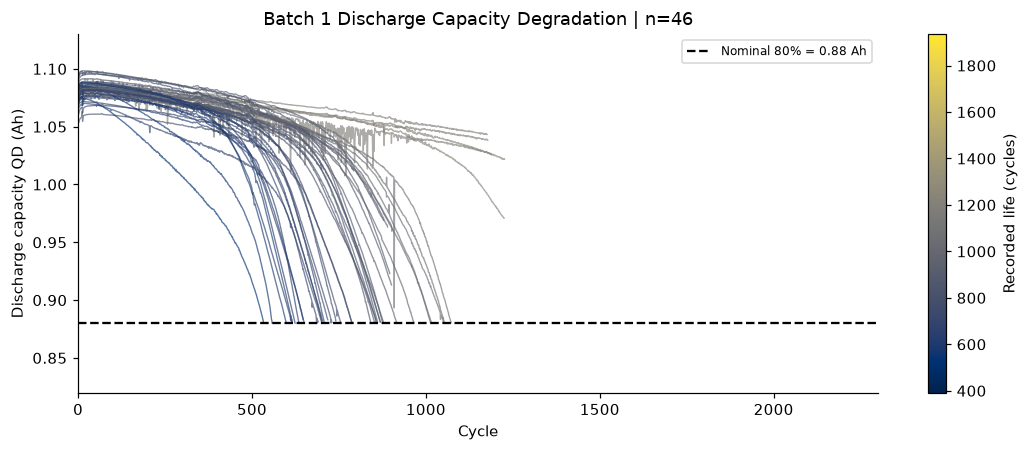

In [15]:
plot_degradation(1)

**Batch 1 해석:** 완만한 감소 후 가속되는 곡선과, 1.0Ah 근처에서 기록이 끝나는 곡선이 함께 있습니다. 후자는 종료·연속 실험 이력을 확인해야 하며 기록된 `cycle_life`를 완전한 EOL 정답으로 바로 해석하기 어렵습니다.

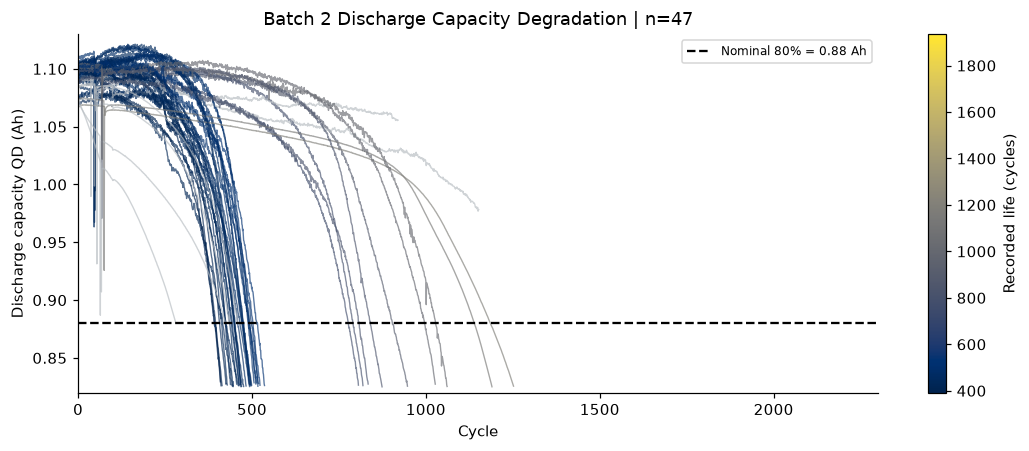

In [16]:
plot_degradation(2)

**Batch 2 해석:** 짧은 수명의 곡선들이 상대적으로 이른 구간에서 빠르게 감소합니다. 긴 수명 곡선도 함께 있어 평균 곡선 한 개로 묶으면 집단 차이가 가려질 수 있습니다. 타깃 결측 셀은 회색으로 표시하고 곡선 탐색에 남겼습니다.

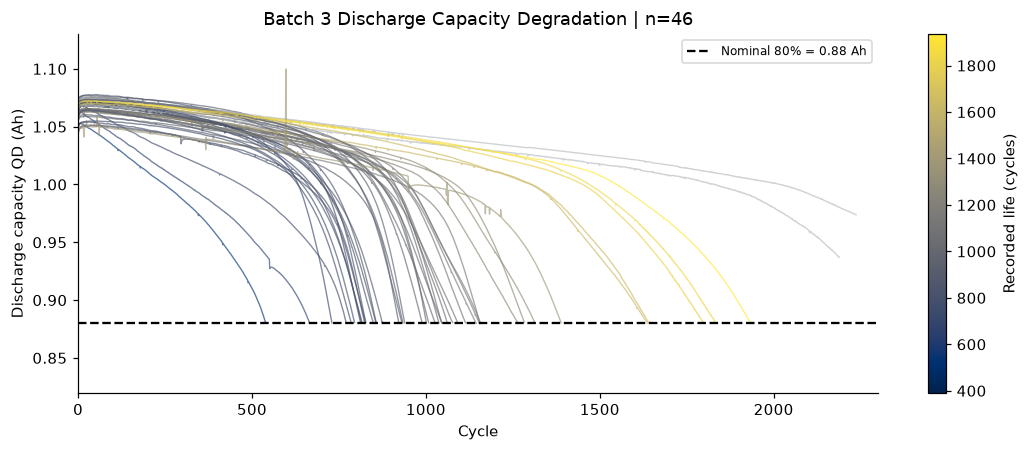

In [17]:
plot_degradation(3)

**Batch 3 해석:** 감소·가속 시점이 넓은 사이클 범위에 분포합니다. 기록 수명 중앙값이 더 길지만 모든 셀이 같은 열화 속도를 갖는 것은 아닙니다. 다른 배치와의 차이를 운전 정책의 인과 효과로 단정하지 않습니다.

### 열화 가속 시점 및 Knee 후보 분석

**실습 설정:** 평활화 창·샘플 간격·SSE 개선 기준을 수정하면 검출 민감도가 달라집니다. 검출률은 물리적 knee의 정확도가 아닙니다. 전체 미래 곡선으로 계산한 knee와 후반 기울기는 초기 예측 입력에서 제외합니다.

In [18]:
KNEE_START_CYCLE, KNEE_SMOOTH_WINDOW, KNEE_STRIDE = 100, 11, 5
KNEE_SSE_RATIO = .70

def find_knee_candidate(group):
    group = group.sort_values("cycle")
    keep = (group.cycle >= KNEE_START_CYCLE) & np.isfinite(group.QD) & (group.QD > 0) & (group.QD < QD_UPPER_AH)
    x = group.loc[keep, "cycle"].to_numpy()[::KNEE_STRIDE]
    y = median_filter(group.loc[keep, "QD"].to_numpy(), size=KNEE_SMOOTH_WINDOW)[::KNEE_STRIDE]
    result = {"knee_cycle": np.nan, "slope_before": np.nan, "slope_after": np.nan, "sse_ratio": np.nan}
    if len(x) < 40:
        return result, None
    base_sse = np.sum((y - np.polyval(np.polyfit(x, y, 1), x))**2)
    best = None
    for cut in range(12, len(x)-12, 3):
        before = np.polyfit(x[:cut], y[:cut], 1)
        after = np.polyfit(x[cut:], y[cut:], 1)
        sse = np.sum((y[:cut]-np.polyval(before, x[:cut]))**2) + np.sum((y[cut:]-np.polyval(after, x[cut:]))**2)
        if best is None or sse < best[0]:
            best = (sse, cut, before, after)
    sse, cut, before, after = best
    if base_sse > 0 and sse/base_sse < KNEE_SSE_RATIO and after[0] < 2*min(before[0], -1e-6):
        result.update(knee_cycle=x[cut], slope_before=before[0], slope_after=after[0], sse_ratio=sse/base_sse)
        return result, (x, y, cut, before, after)
    return result, None

knee_rows, knee_curves = [], {}
for cell_id, group in df.groupby("cell_id", sort=False):
    result, fit = find_knee_candidate(group)
    knee_rows.append({"cell_id": cell_id, "batch": int(group.batch.iloc[0]), **result})
    if fit is not None:
        knee_curves[cell_id] = fit
knee_analysis = pd.DataFrame(knee_rows)
knee_summary = knee_analysis.groupby("batch").agg(raw_n=("cell_id", "size"),
    detected_n=("knee_cycle", "count"), median_knee=("knee_cycle", "median"),
    Q1=("knee_cycle", lambda x: x.quantile(.25)), Q3=("knee_cycle", lambda x: x.quantile(.75)))
knee_summary["no_candidate_n"] = knee_summary.raw_n - knee_summary.detected_n
display(knee_summary.round(1))

,raw_n,detected_n,median_knee,Q1,Q3,no_candidate_n
batch,,,,,,
1,46,43,640.0,535.0,692.5,3
2,47,44,370.0,355.0,415.0,3
3,46,45,850.0,685.0,985.0,1


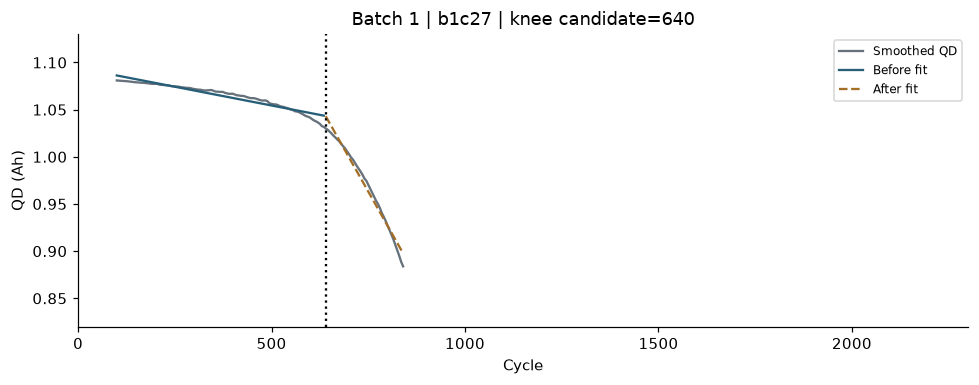

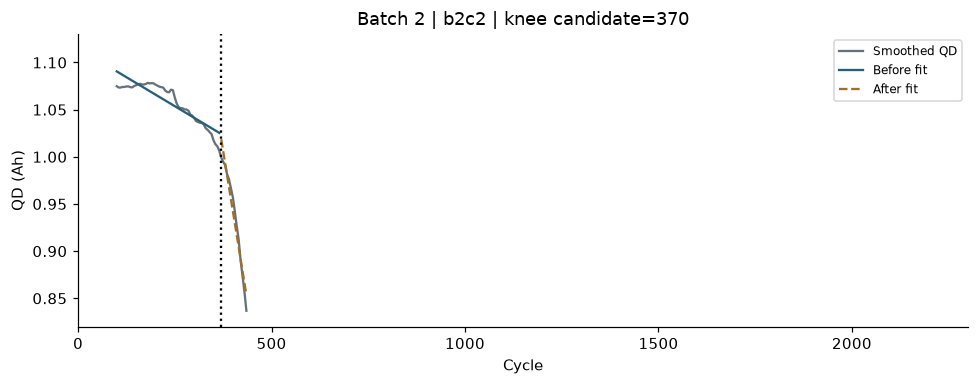

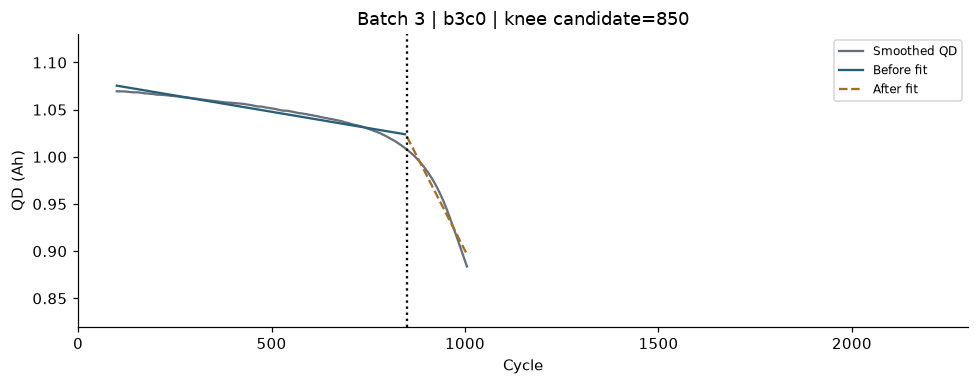

,batch,cell_id,knee_cycle,before_Ah_per_cycle,after_Ah_per_cycle,speed_ratio
0,1,b1c27,640.0,-0.000080,-0.000727,9.130960
1,2,b2c2,370.0,-0.000246,-0.002539,10.333350
2,3,b3c0,850.0,-0.000069,-0.000804,11.631829


In [19]:
representative_knees = []
for batch_no in BATCH_FILES:
    group = knee_analysis[(knee_analysis.batch == batch_no) & knee_analysis.knee_cycle.notna()]
    if group.empty:
        continue
    median_knee = group.knee_cycle.median()
    usable = group[group.cell_id.isin(valid_targets.cell_id)]
    if usable.empty:
        continue
    row = usable.loc[(usable.knee_cycle - median_knee).abs().idxmin()]
    x, y, cut, before, after = knee_curves[row.cell_id]
    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax.plot(x, y, color=GRAY, label="Smoothed QD")
    ax.plot(x[:cut], np.polyval(before, x[:cut]), color=BLUE, label="Before fit")
    ax.plot(x[cut:], np.polyval(after, x[cut:]), color=GOLD, linestyle="--", label="After fit")
    ax.axvline(x[cut], color="black", linestyle=":")
    ax.set(xlabel="Cycle", ylabel="QD (Ah)", title=f"Batch {batch_no} | {row.cell_id} | knee candidate={x[cut]:.0f}")
    ax.set_xlim(0, 2300)
    ax.set_ylim(.82, 1.13)
    ax.legend(fontsize=8)
    show_and_save(f"q2_knee_b{batch_no}")
    representative_knees.append({"batch": batch_no, "cell_id": row.cell_id, "knee_cycle": x[cut],
        "before_Ah_per_cycle": before[0], "after_Ah_per_cycle": after[0],
        "speed_ratio": abs(after[0]/before[0]) if before[0] < 0 else np.nan})
representative_knees = pd.DataFrame(representative_knees)
display(representative_knees.round(6))

### 배치 비교 및 모델 설계 시사점

**열화는 한 가지 속도로 진행되지 않습니다.** knee 후보 중앙값은 Batch 1 640, Batch 2 370, Batch 3 850사이클이고 대표 셀의 후반 감소 속도는 전반의 약 9–12배입니다. 초기 기울기를 전체 수명으로 단순 외삽하기보다 초기 용량·변화량·운전 맥락을 함께 표현하는 피처 설계가 필요합니다.

**라벨의 의미를 확인하는 일이 모델 선택보다 앞섭니다.** Batch 1의 유효 타깃 46셀 중 13셀은 EOL 근처 종료 기준을 만족하지 않습니다. 이 하위집단의 마지막 유효 용량 중앙값은 약 0.965Ah입니다. 기록된 `cycle_life`를 완전한 EOL 정답으로 해석하기 전에 종료·연속 실험 이력을 확인해야 합니다. EOL 근처 집단은 라벨 선택의 민감도를 비교하는 대리 기준으로 사용합니다.

**탐색 정보와 예측 시점의 입력을 구분합니다.** 전체 곡선에서 찾은 knee는 열화 형태를 설명하지만 초기 관측 시점에는 알 수 없는 값입니다. 입력은 초기 cycle≤100의 관측값으로 구성하고 미래 곡선은 라벨·형태 점검에 사용합니다.

## 3. 초기 방전 곡선 변화량과 수명 연관성

**원래 질문:** 초기 사이클에서 ΔQ 곡선 차이가 보이는가?

**구체화한 질문:** Q100(V)−Q10(V)의 형태와 통계량이 장·단수명을 구분하는 신호인가? 평균·최솟값·분산 중 어떤 요약값을 기본 피처로 둘 근거가 있는가?

같은 전압 축에서 실제 cycle 100과 10을 비교합니다. 원자료의 전압 축은 2.0–3.5V이며 3.6V를 가정하지 않습니다.

In [20]:
delta_rows = []
for cell_id, curve in curve_records.items():
    delta = curve["Q100"] - curve["Q10"]
    curve["delta"] = delta
    valid_curve = np.isfinite(delta).all()
    delta_rows.append({"cell_id": cell_id, "curve_valid": valid_curve,
        "logvar_deltaQ": np.log10(max(np.var(delta, ddof=1), 1e-15)) if valid_curve else np.nan,
        "min_deltaQ": np.min(delta) if valid_curve else np.nan,
        "mean_deltaQ": np.mean(delta) if valid_curve else np.nan})
delta_features = pd.DataFrame(delta_rows)
cells_delta = cells.merge(delta_features, on="cell_id", validate="one_to_one")
display(delta_features.head())

,cell_id,curve_valid,logvar_deltaQ,min_deltaQ,mean_deltaQ
0,b1c0,True,-5.014427,-0.008460,-0.002873
1,b1c1,True,-5.013525,-0.011004,-0.004100
2,b1c2,True,-4.736565,-0.017216,-0.004487
3,b1c3,True,-4.442179,-0.018961,-0.007456
4,b1c4,True,-4.647309,-0.013958,-0.005750


In [21]:
def plot_delta_groups(batch_no):
    group=cells_delta[(cells_delta.batch==batch_no)&cells_delta.cycle_life.notna()&cells_delta.curve_valid]
    fig,ax=plt.subplots(figsize=(9,3.3))
    for label,condition,color,style in [(f'Short <{SHORT_LIFE}',group.cycle_life<SHORT_LIFE,GOLD,'--'),(f'Long >{LONG_LIFE}',group.cycle_life>LONG_LIFE,BLUE,'-')]:
        ids=group.loc[condition,'cell_id']
        if ids.empty:continue
        voltage=curve_records[ids.iloc[0]]['V']
        assert all(np.allclose(curve_records[cid]['V'],voltage) for cid in ids)
        values=np.array([curve_records[cid]['delta'] for cid in ids])
        ax.plot(voltage,np.median(values,axis=0),color=color,linestyle=style,label=f'{label} n={len(ids)}')
        ax.fill_between(voltage,np.quantile(values,.25,axis=0),np.quantile(values,.75,axis=0),color=color,alpha=.15)
    ax.set(title=f'Batch {batch_no} Early-Cycle Delta-Q by Lifetime Group',xlabel='Voltage (V)',ylabel='Q100(V) - Q10(V) (Ah)',xlim=(2,3.5),ylim=(-.075,.01))
    ax.legend(fontsize=8)
    show_and_save(f'q3_delta_groups_b{batch_no}')

### 초기 방전 곡선 변화량 분석 · Batch 1

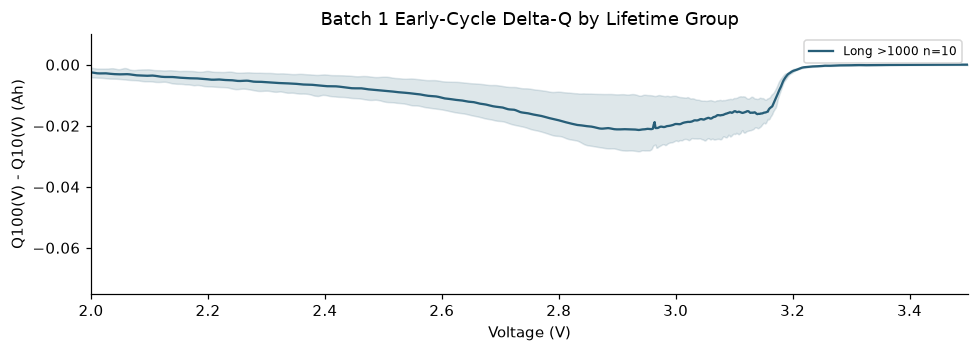

In [22]:
plot_delta_groups(1)

Batch 1은 기본 <500 단수명 그룹이 없어 장수명 곡선만 표시했습니다. 두 그룹을 구분하는 모양의 차이는 이 배치에서 직접 비교할 수 없습니다.

### 초기 방전 곡선 변화량 분석 · Batch 2

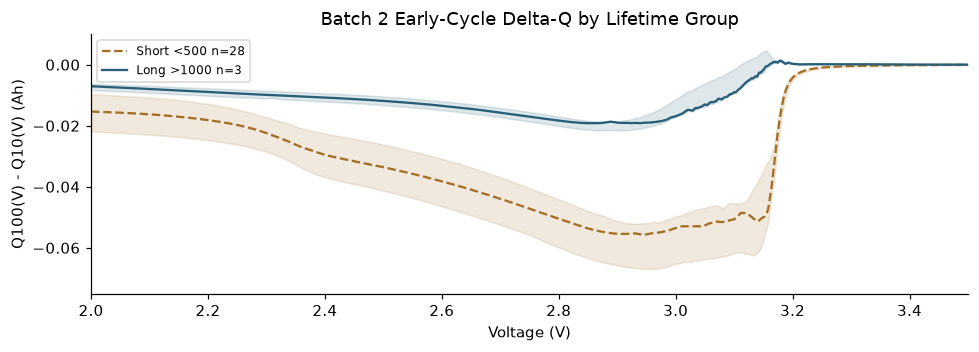

In [23]:
plot_delta_groups(2)

Batch 2는 단수명 28셀과 장수명 3셀의 곡선을 비교할 수 있습니다. 단수명 중앙 곡선의 음의 변화가 크지만 장수명 표본이 작습니다.

### 초기 방전 곡선 변화량 분석 · Batch 3

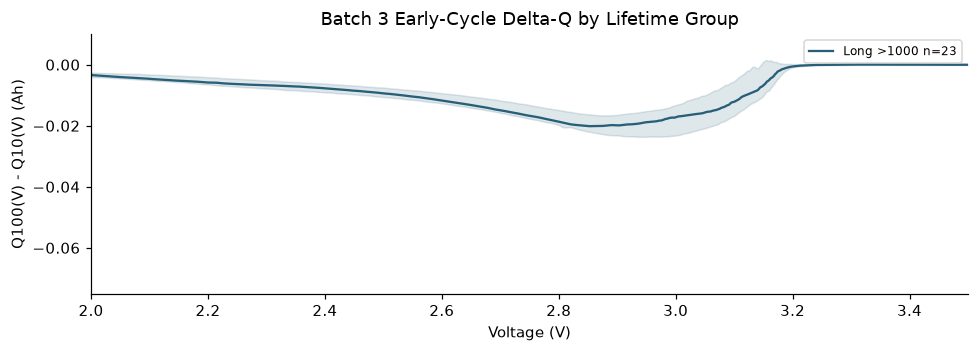

In [24]:
plot_delta_groups(3)

Batch 3도 기본 <500 단수명 그룹이 없습니다. 장수명 23셀의 곡선은 제시하되 없는 단수명 곡선을 만들지 않습니다.

### 분석 집단 정의 및 상관 분석

그룹 곡선은 전체 유효 타깃을 사용했습니다. 아래 상관 그림은 선택한 대상과 표본 수를 제목에 표시합니다. `RELATION_COHORT`를 변경해 전체 타깃과 종료 조건 하위집단을 비교할 수 있습니다.

In [25]:
# 실습 설정: "all_targets" 또는 "eol_near"
RELATION_COHORT = "eol_near"

def select_cohort(data, cohort):
    result = data[data.cycle_life.notna()].copy()
    if cohort == "eol_near":
        result = result[result.eol_near]
    elif cohort != "all_targets":
        raise ValueError("cohort은 all_targets 또는 eol_near입니다.")
    return result

def pair_stats(data, x, y):
    pair = data[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    return {"n": len(pair), "pearson": pair[x].corr(pair[y]),
            "spearman": pair[x].corr(pair[y], method="spearman")}

delta_correlations = pd.DataFrame([
    {"cohort": cohort, "batch": batch_no, **pair_stats(group, "logvar_deltaQ", "cycle_life")}
    for cohort in ["all_targets", "eol_near"]
    for batch_no, group in select_cohort(cells_delta, cohort).groupby("batch")
])
display(delta_correlations.round(3))

,cohort,batch,n,pearson,spearman
0,all_targets,1,46,-0.886,-0.871
1,all_targets,2,39,-0.902,-0.709
2,all_targets,3,44,-0.702,-0.797
3,eol_near,1,33,-0.831,-0.841
4,eol_near,2,39,-0.902,-0.709
5,eol_near,3,44,-0.702,-0.797


In [26]:
def plot_delta_life(batch_no):
    relation=select_cohort(cells_delta,RELATION_COHORT)
    group=relation[relation.batch==batch_no]
    pair=group[['logvar_deltaQ','cycle_life']].dropna()
    stats=pair_stats(group,'logvar_deltaQ','cycle_life')
    all_x=relation.logvar_deltaQ.dropna()
    fig,ax=plt.subplots(figsize=(9,3.3))
    ax.scatter(pair.logvar_deltaQ,pair.cycle_life,color=BLUE,alpha=.8)
    ax.set(title=f'Batch {batch_no} Delta-Q Variance and Cycle Life | {RELATION_COHORT} | n={stats["n"]}',xlabel='log10 sample variance of Delta-Q',ylabel='Recorded life (cycles)',xlim=(all_x.min()-.2,all_x.max()+.2),ylim=(150,2300))
    show_and_save(f'q3_delta_life_b{batch_no}')
    display(Markdown(f'**Batch {batch_no} 관찰:** 동일한 산점도 대상의 Pearson r={stats["pearson"]:+.3f}, Spearman ρ={stats["spearman"]:+.3f}, n={stats["n"]}.'))

### ΔQ 피처의 수명 연관성 · Batch 1

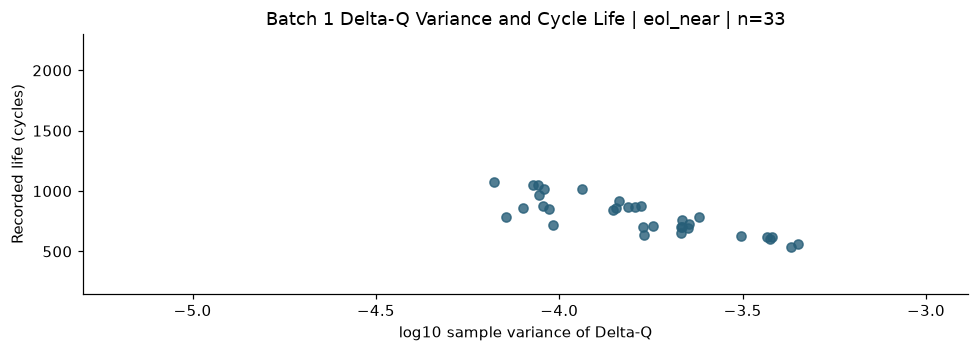

**Batch 1 관찰:** 동일한 산점도 대상의 Pearson r=-0.831, Spearman ρ=-0.841, n=33.

In [27]:
plot_delta_life(1)

음의 수명 연관을 초기 후보 신호로 사용하되, 전체 타깃과 EOL 근처 집단을 구분합니다.

### ΔQ 피처의 수명 연관성 · Batch 2

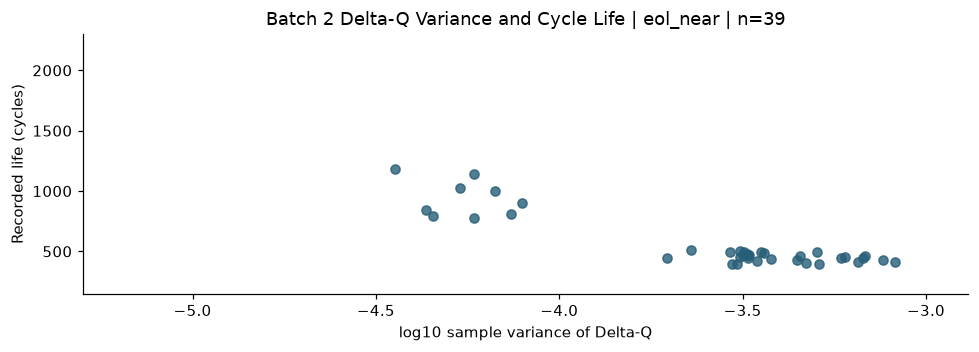

**Batch 2 관찰:** 동일한 산점도 대상의 Pearson r=-0.902, Spearman ρ=-0.709, n=39.

In [28]:
plot_delta_life(2)

음의 연관이 있으나 전체 배치 특성까지 설명하는 하나의 법칙으로 해석하지 않습니다.

### ΔQ 피처의 수명 연관성 · Batch 3

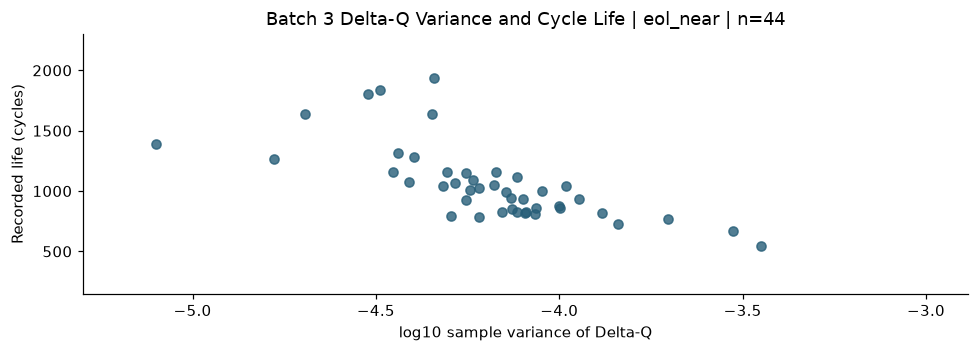

**Batch 3 관찰:** 동일한 산점도 대상의 Pearson r=-0.702, Spearman ρ=-0.797, n=44.

In [29]:
plot_delta_life(3)

음의 연관은 유지되지만 다른 배치와 계수 크기가 다릅니다. 외부 배치 일반화 검증이 필요합니다.

### 배치 비교 및 모델 설계 시사점

**초기 상태보다 변화 양상이 수명 신호를 더 잘 드러냅니다.** ΔQ 로그 분산은 세 배치의 EOL 근처 집단에서 일관된 음의 상관(r=−0.831/−0.902/−0.702)을 보입니다. 초기 QD2의 배치 내 상관은 +0.086/−0.284/+0.155로 약하고 방향도 다릅니다. 정상 범위의 비슷한 초기 용량 안에서도 변화량에는 수명 차이의 정보가 담깁니다.

**그룹 비교의 가능 범위를 명확히 합니다.** 기본 <500 단수명 그룹은 Batch 2에만 존재합니다. 단수명 28셀의 ΔQ 중앙 곡선은 장수명 3셀보다 더 깊지만, 이 모양 차이를 Batch 1·3에서도 확인한 것으로 일반화하지 않습니다.

**피처 선정은 배치 간 신호의 일관성과 정보 중복을 함께 봅니다.** 로그 분산 하나를 기준 입력으로 두고 최솟값·평균의 추가 여부를 비교합니다. 여러 배치에서 같은 방향을 보이는 관계는 후보 선정의 근거이며, 예측 기여도의 기준은 정책 그룹 검증 오차와 배치별 안정성입니다.

## 4. 충전 조건과 열화·수명 관계 분석

**원래 질문:** 고속 충전 셀의 수명은 정말 짧은가?

**구체화한 질문:** C1 하나의 관계가 세 배치에서 일관되는가? C1·전환 SOC·C2와 초기 용량 기울기는 어떻게 연결되는가? 정책 평균의 차이를 새 정책에서의 예측 검증 설계에 어떻게 반영할 수 있는가?

정책 문자열의 C-rate와 함께 초기 cycle 2–100의 실제 I(t) 파형을 분석합니다. 공칭 0–80% 충전 구간에서 평균·RMS 전류, 단계 변동계수와 고전류 충전량 비중을 정의하고, 초기 QD 기울기 및 기록 수명과의 관계를 배치별로 확인합니다.

In [30]:
policy_rows = []
for row in cells.itertuples():
    match = re.search(r"([\d.]+)C\(([\d.]+)%\)-([\d.]+)C", row.charging_policy)
    values = list(map(float, match.groups())) if match else [np.nan] * 3
    policy_rows.append({"cell_id": row.cell_id, "C1": values[0], "SOC_switch": values[1], "C2": values[2]})
policy_features = pd.DataFrame(policy_rows)

slope_rows = []
for cell_id, group in df.groupby("cell_id", sort=False):
    early = group[group.cycle.between(EARLY_START, EARLY_END)]
    keep = np.isfinite(early.QD) & (early.QD > 0) & (early.QD < QD_UPPER_AH)
    slope = np.polyfit(early.loc[keep, "cycle"], early.loc[keep, "QD"], 1)[0] if keep.sum() > 2 else np.nan
    slope_rows.append({"cell_id": cell_id, "slope_QD": slope})
qd_slopes = pd.DataFrame(slope_rows)
cells_charge = cells_delta.merge(policy_features, on="cell_id", validate="one_to_one").merge(qd_slopes, on="cell_id", validate="one_to_one")
print("정책에서 C-rate를 추출하지 못한 셀:")
display(cells_charge.loc[cells_charge.C1.isna(), ["cell_id", "cycle_life", "charging_policy"]])

정책에서 C-rate를 추출하지 못한 셀:


,cell_id,cycle_life,charging_policy
68,b2c22,NaN,VarCharge-2C-100cycles
69,b2c23,NaN,VarCharge-4C-100cycles
81,b2c35,NaN,VarCharge-6C-100cycles
82,b2c36,NaN,VarCharge-8C-100cycles


In [31]:
policy_summary = cells.groupby(["batch", "charging_policy"]).agg(
    mean_life=("cycle_life", "mean"), std_life=("cycle_life", "std"),
    raw_n=("cell_id", "size"), target_n=("cycle_life", "count")
).reset_index()
policy_summary["missing_target_n"] = policy_summary.raw_n - policy_summary.target_n

def plot_policy_means(batch_no):
    group = policy_summary[policy_summary.batch == batch_no].sort_values("mean_life", na_position="last").reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(10, max(3.5, len(group)*.27+1)))
    for index, row in group.iterrows():
        if np.isfinite(row.mean_life):
            ax.plot(row.mean_life, index, "o", color=BLUE, markersize=5)
            if row.target_n >= 2:
                ax.hlines(index, row.mean_life-row.std_life, row.mean_life+row.std_life, color=GRAY)
            ax.text(2320, index, f"n={int(row.target_n)}", va="center", fontsize=9)
        else:
            ax.text(30, index, f"No target (raw n={int(row.raw_n)})", color=GRAY, va="center", fontsize=9)
    ax.set_yticks(range(len(group)), group.charging_policy, fontsize=9)
    ax.set(xlim=(0, 2600), xlabel="Mean recorded life (cycles); line = sample SD",
           title=f"Batch {batch_no} | {len(group)} policies | target n={group.target_n.sum()}")
    ax.grid(axis="x", color="#E3E7EA", linewidth=.6)
    show_and_save(f"q4_policy_b{batch_no}")

### 충전 프로토콜별 수명 통계 · Batch 1

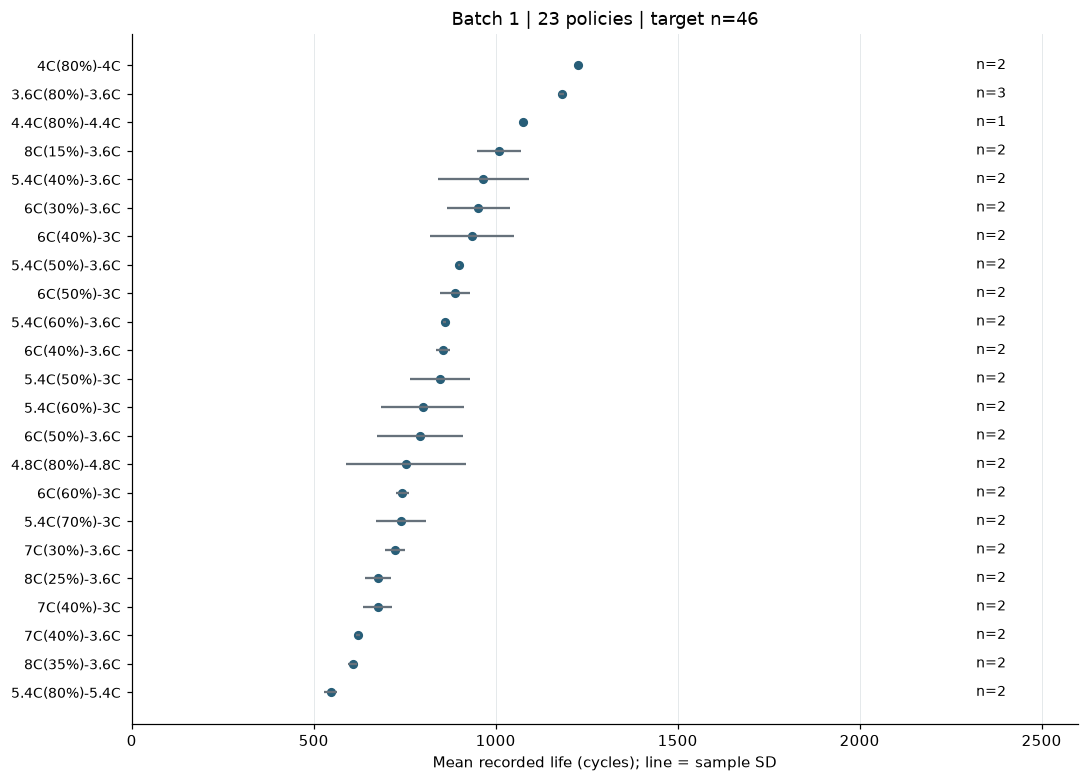

In [32]:
plot_policy_means(1)

Batch 1의 23개 정책 대부분은 2셀입니다. 정책 평균은 탐색적 비교이며 최적 조건을 확정하는 근거가 아닙니다.

### 충전 프로토콜별 수명 통계 · Batch 2

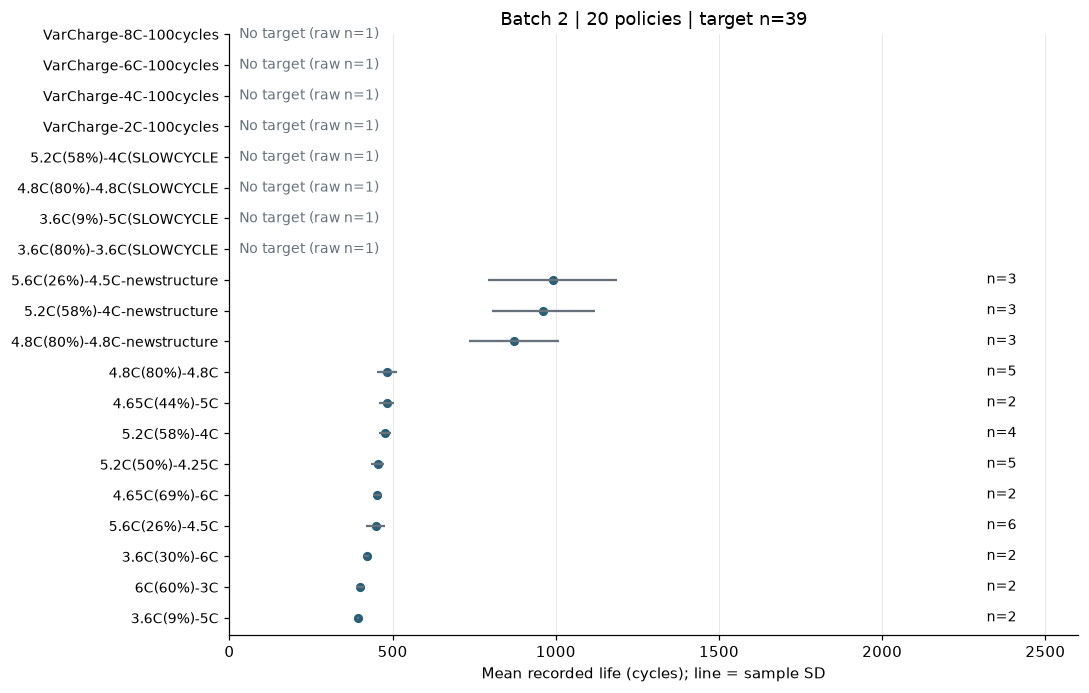

In [33]:
plot_policy_means(2)

Batch 2의 20개 정책 중 8개는 타깃이 전부 결측입니다. 이 정책은 평균을 만들지 않고 결측으로 표시합니다.

### 충전 프로토콜별 수명 통계 · Batch 3

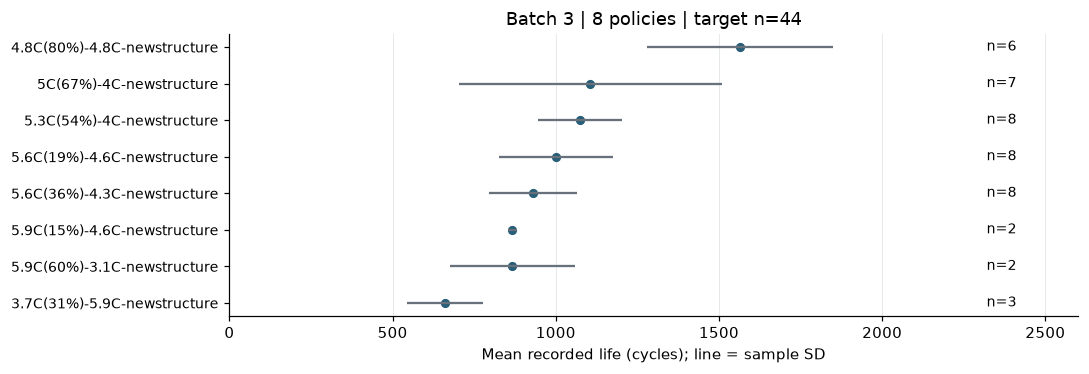

In [34]:
plot_policy_means(3)

Batch 3의 8개 정책에는 newstructure 조건이 포함됩니다. C-rate 숫자만 같다고 다른 배치의 동일 정책으로 합치지 않습니다.

In [35]:
# 모든 원본 정책을 유지하고 결측 정책을 별도로 확인합니다.
policy_counts = policy_summary.groupby("batch").agg(
    policies=("charging_policy", "size"), raw_cells=("raw_n", "sum"),
    target_cells=("target_n", "sum"), missing_target_cells=("missing_target_n", "sum"),
    policies_without_target=("target_n", lambda x: (x == 0).sum()))
display(policy_counts)
display(policy_summary.sort_values(["batch", "mean_life"]).round(2))

,policies,raw_cells,target_cells,missing_target_cells,policies_without_target
batch,,,,,
1,23,46,46,0,0
2,20,47,39,8,8
3,8,46,44,2,0


,batch,charging_policy,mean_life,std_life,raw_n,target_n,missing_target_n
10,1,5.4C(80%)-5.4C,546.50,17.68,2,2,0
22,1,8C(35%)-3.6C,607.50,12.02,2,2,0
18,1,7C(40%)-3.6C,621.00,5.66,2,2,0
19,1,7C(40%)-3C,676.00,39.60,2,2,0
21,1,8C(25%)-3.6C,676.50,36.06,2,2,0
17,1,7C(30%)-3.6C,722.50,27.58,2,2,0
9,1,5.4C(70%)-3C,739.50,68.59,2,2,0
16,1,6C(60%)-3C,744.00,18.38,2,2,0
2,1,4.8C(80%)-4.8C,753.00,165.46,2,2,0
14,1,6C(50%)-3.6C,792.50,118.09,2,2,0


In [36]:
charging_correlations = []
for cohort in ["all_targets", "eol_near"]:
    for batch_no, group in select_cohort(cells_charge, cohort).groupby("batch"):
        for x, y in [("C1", "cycle_life"), ("C1", "slope_QD"), ("C2", "slope_QD"), ("SOC_switch", "slope_QD")]:
            charging_correlations.append({"cohort": cohort, "batch": batch_no, "x": x, "y": y, **pair_stats(group, x, y)})
charging_correlations = pd.DataFrame(charging_correlations)
display(charging_correlations.round(3))

,cohort,batch,x,y,n,pearson,spearman
0,all_targets,1,C1,cycle_life,46,-0.580,-0.483
1,all_targets,1,C1,slope_QD,46,-0.200,-0.491
2,all_targets,1,C2,slope_QD,46,-0.510,-0.057
3,all_targets,1,SOC_switch,slope_QD,46,-0.107,0.191
4,all_targets,2,C1,cycle_life,39,0.191,0.055
5,all_targets,2,C1,slope_QD,39,0.114,-0.070
6,all_targets,2,C2,slope_QD,39,-0.337,-0.134
7,all_targets,2,SOC_switch,slope_QD,39,0.087,0.017
8,all_targets,3,C1,cycle_life,44,-0.083,-0.229
9,all_targets,3,C1,slope_QD,44,0.718,-0.093


In [37]:
def plot_charge_relation(batch_no,y):
    relation=select_cohort(cells_charge,'all_targets')
    group=relation[relation.batch==batch_no]
    pair=group[['C1',y]].dropna()
    stats=pair_stats(group,'C1',y)
    scale=1e4 if y=='slope_QD' else 1
    fig,ax=plt.subplots(figsize=(9,3.3))
    ax.scatter(pair.C1,pair[y]*scale,color=BLUE,alpha=.8)
    all_y=relation[y].dropna()*scale
    span=all_y.max()-all_y.min()
    ylim=(150,2300) if y=='cycle_life' else (all_y.min()-.05*span,all_y.max()+.05*span)
    ax.set(title=f'Batch {batch_no}: Charge Rate and {"Cycle Life" if y=="cycle_life" else "Early Capacity Slope"} | n={stats["n"]}',xlabel='C1 (C)',ylabel='Life (cycles)' if y=='cycle_life' else 'QD slope (1e-4 Ah/cycle)',xlim=(relation.C1.min()-.2,relation.C1.max()+.2),ylim=ylim)
    if y=='slope_QD':ax.axhline(0,color=GRAY,linestyle=':')
    show_and_save(f'q4_C1_vs_{y}_b{batch_no}')
    display(Markdown(f'**Batch {batch_no} · {y}:** Pearson r={stats["pearson"]:+.3f}, Spearman ρ={stats["spearman"]:+.3f}, n={stats["n"]}.'))

### 충전 조건과 열화·수명 관계 · Batch 1

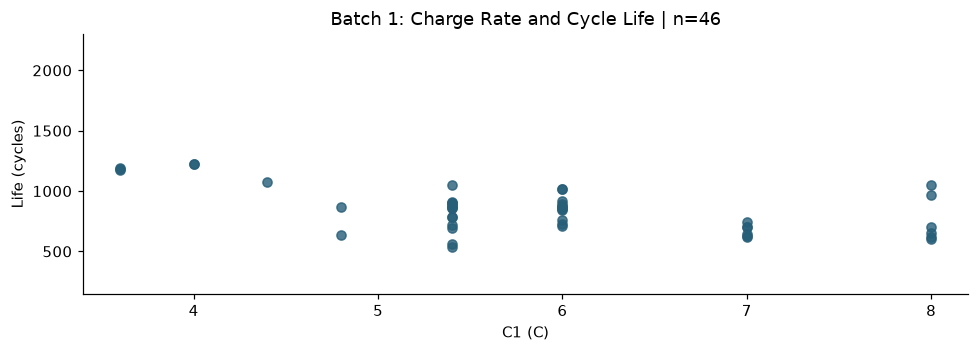

**Batch 1 · cycle_life:** Pearson r=-0.580, Spearman ρ=-0.483, n=46.

In [38]:
plot_charge_relation(1, "cycle_life")

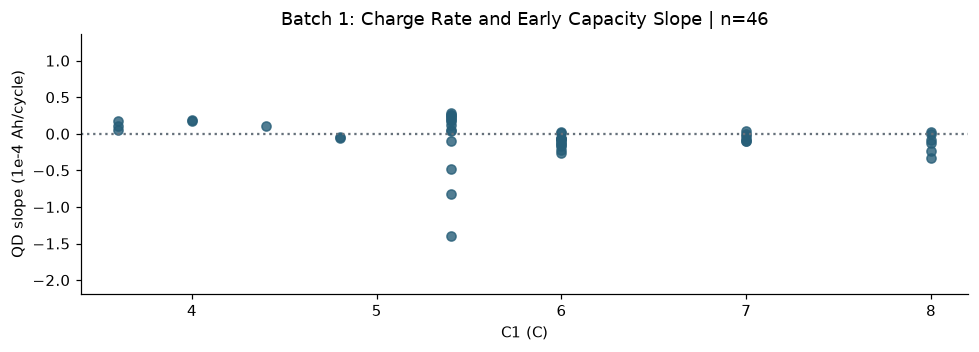

**Batch 1 · slope_QD:** Pearson r=-0.200, Spearman ρ=-0.491, n=46.

In [39]:
plot_charge_relation(1, "slope_QD")

Batch 1의 C1–수명 관계는 음수지만 EOL 근처 집단에서는 약해집니다. 라벨·대상 선택의 영향을 함께 봅니다.

### 충전 조건과 열화·수명 관계 · Batch 2

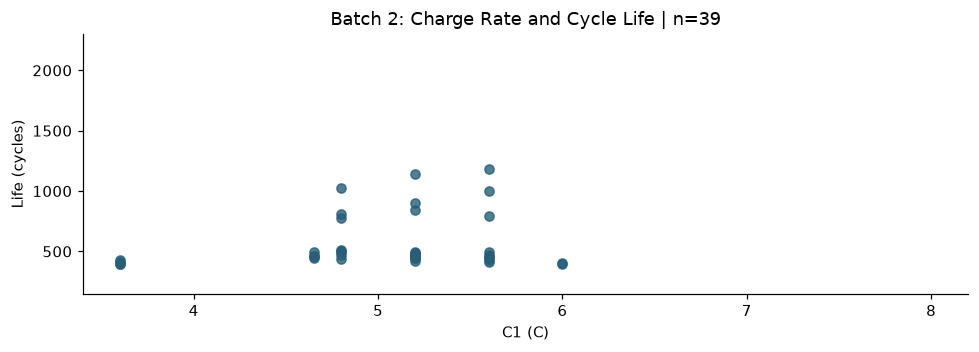

**Batch 2 · cycle_life:** Pearson r=+0.191, Spearman ρ=+0.055, n=39.

In [40]:
plot_charge_relation(2, "cycle_life")

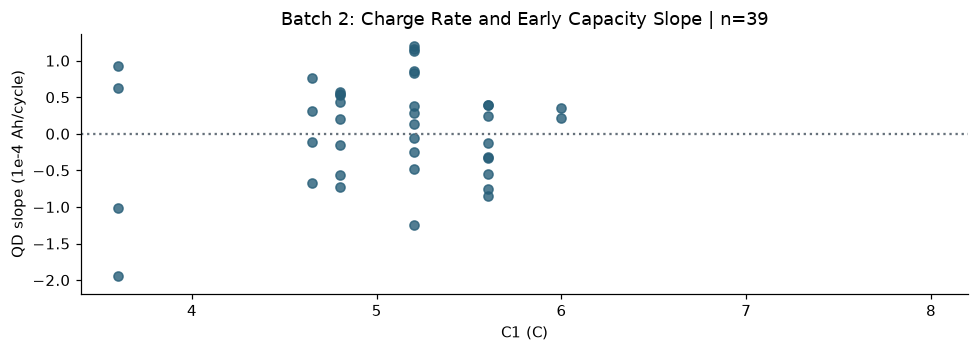

**Batch 2 · slope_QD:** Pearson r=+0.114, Spearman ρ=-0.070, n=39.

In [41]:
plot_charge_relation(2, "slope_QD")

Batch 2의 C1–수명 관계는 약한 양수입니다. 고속 충전이면 언제나 짧은 수명이라는 단일 설명과 일치하지 않습니다.

### 충전 조건과 열화·수명 관계 · Batch 3

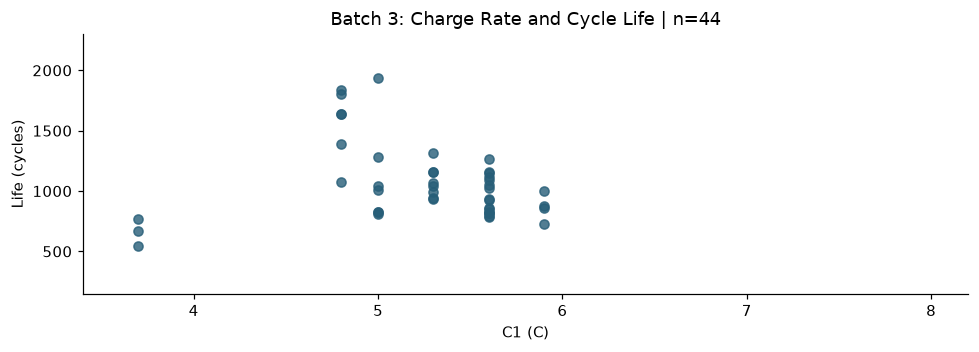

**Batch 3 · cycle_life:** Pearson r=-0.083, Spearman ρ=-0.229, n=44.

In [42]:
plot_charge_relation(3, "cycle_life")

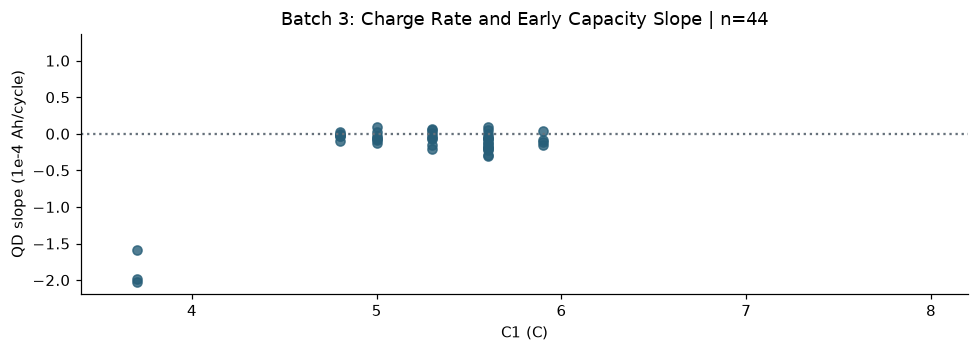

**Batch 3 · slope_QD:** Pearson r=+0.718, Spearman ρ=-0.093, n=44.

In [43]:
plot_charge_relation(3, "slope_QD")

Batch 3의 C1–수명 관계는 약합니다. C1–초기 기울기의 Pearson과 Spearman 차이는 극단값 민감성을 시사합니다.

### 실제 충전 전류의 단위 및 구간 정의

원본 `I`는 C-rate로 정규화되어 있고 `t`는 분입니다. 안정 구간의 `(dQc/dt)×60/I`가 약1.1인 점과 `1.1×∫I dt/60`의 충전량 일치로 단위를 확인합니다. 공칭0–80%=0.88Ah 교차 전까지 분석하고, 부호가 바뀐 방전 구간과 이후 추가 충전을 구분합니다. 같은 시각의 기록은 적분 기여0으로 처리합니다.

시간 가중 통계는 불균등 측정 간격을 반영합니다. 초기 cycle2–100의 유효 파형을 셀별 평균으로 집계해 **셀당 한 행**을 유지합니다. 60분 초과 또는 전류 적분·충전량 차이5% 초과 구간은 품질 검토 표에 기록합니다. 4.5C는 고전류 노출을 비교하기 위한 탐색 문턱값입니다.

In [44]:
# Reused verbatim as a notebook code cell.
CURRENT_START, CURRENT_END = EARLY_START, EARLY_END
HIGH_CURRENT_C = 4.5
CURRENT_MAX_DURATION_MIN=60
CURRENT_INTEGRAL_TOLERANCE=.05
FAST_CHARGE_AH = .8 * NOMINAL_AH
CURRENT_INPUT_FIELDS = ['current_mean_C', 'current_rms_C', 'current_cv', 'high_current_charge_fraction']

def charge_pattern(t, current_c, qc):
    """0~공칭80% 충전의 시간 가중 통계. 원본 I는 C-rate, t는 분입니다."""
    t, current_c, qc = map(lambda a: np.asarray(a, dtype=float), (t, current_c, qc))
    if not (len(t)==len(current_c)==len(qc)) or len(t)<3:
        return None
    neg = np.flatnonzero(current_c < -.05)
    limit = int(neg[0]) if len(neg) else len(t)
    crossing = np.flatnonzero((qc[:limit]>=FAST_CHARGE_AH)&np.isfinite(qc[:limit]))
    if not len(crossing):
        return None
    end = int(crossing[0])
    t, current_c, qc = t[:end+1].copy(), current_c[:end+1].copy(), qc[:end+1].copy()
    if not np.all(np.isfinite(t)&np.isfinite(current_c)&np.isfinite(qc)) or np.any(np.diff(t)<-1e-8):
        return None
    # 마지막 구간의 0.88Ah 교차 시점을 선형 보간합니다.
    if end>0 and qc[-1]>qc[-2] and qc[-2]<FAST_CHARGE_AH:
        fraction=(FAST_CHARGE_AH-qc[-2])/(qc[-1]-qc[-2])
        t[-1]=t[-2]+fraction*(t[-1]-t[-2])
        current_c[-1]=current_c[-2]+fraction*(current_c[-1]-current_c[-2])
        qc[-1]=FAST_CHARGE_AH
    dt=np.diff(t)
    keep=dt>1e-8
    dt=dt[keep]
    c0=np.maximum(current_c[:-1][keep],0);c1=np.maximum(current_c[1:][keep],0)
    cm=(c0+c1)/2
    duration=dt.sum()
    if duration<=0 or not len(dt):return None
    integral=np.sum(cm*dt)
    mean=integral/duration
    # 구간 내 선형 전류의 제곱 적분은 (c0²+c0*c1+c1²)/3입니다.
    square_integral=np.sum((c0*c0+c0*c1+c1*c1)/3*dt)
    rms=np.sqrt(square_integral/duration)
    cv=np.sqrt(max(rms*rms-mean*mean,0))/mean if mean>0 else np.nan
    high=np.sum(cm*dt*(cm>HIGH_CURRENT_C))/integral if integral>0 else np.nan
    # dQc/dt와 원본 I를 독립 비교하여 C-rate 정규화 및 시간 단위를 점검합니다.
    dq=np.diff(qc)[keep]
    stable=(cm>1)&(dt>1e-4)&(dq>0)&(dq<.05)&(np.abs(c1-c0)<.02)
    unit_ratio=np.median(dq[stable]*60/(cm[stable]*dt[stable])) if stable.any() else np.nan
    return {'current_mean_C':mean,'current_rms_C':rms,'current_cv':cv,
            'high_current_charge_fraction':high,'fast_charge_duration_min':duration,
            'current_unit_ratio_A_per_C':unit_ratio,
            'charge_integral_ratio':NOMINAL_AH*integral/60/(qc[-1]-qc[0]),
            'zero_time_intervals':int((~keep).sum()),
            't':t,'current_c':current_c}

### 초기 사이클 전류 피처 추출 및 품질 점검

In [45]:
current_rows, current_waveforms = [], {}
current_failed=[]
for batch_no,name in BATCH_FILES.items():
    with h5py.File(DATA_DIR/name,'r') as handle:
        batch=handle['batch']
        for index in range(batch['summary'].shape[0]):
            cell_id=f'b{batch_no}c{index}'
            summary=handle[batch['summary'][index,0]]
            cycles=vector(summary['cycle'])
            curve_group=handle[batch['cycles'][index,0]]
            for actual_index in np.flatnonzero((cycles>=CURRENT_START)&(cycles<=CURRENT_END)):
                cycle=int(cycles[actual_index])
                arrays={k:vector(handle[curve_group[k][actual_index,0]]) for k in ['I','t','Qc']}
                pattern=charge_pattern(arrays['t'],arrays['I'],arrays['Qc'])
                if pattern is None:
                    current_failed.append({'cell_id':cell_id,'batch':batch_no,'cycle':cycle,'reason':'invalid_time_or_missing_80pct_endpoint'})
                    continue
                if pattern['fast_charge_duration_min']>CURRENT_MAX_DURATION_MIN or abs(pattern['charge_integral_ratio']-1)>CURRENT_INTEGRAL_TOLERANCE:
                    current_failed.append({'cell_id':cell_id,'batch':batch_no,'cycle':cycle,'reason':'duration_or_charge_integral_inconsistent',
                                           'duration_min':pattern['fast_charge_duration_min'],'integral_ratio':pattern['charge_integral_ratio']})
                    continue
                if cycle==10:current_waveforms[cell_id]={'t':pattern['t'],'current_c':pattern['current_c']}
                current_rows.append({'cell_id':cell_id,'batch':batch_no,'cycle':cycle,
                                     **{k:v for k,v in pattern.items() if k not in ['t','current_c']}})
current_cycles=pd.DataFrame(current_rows)
current_rejected=pd.DataFrame(current_failed)
current_features=current_cycles.groupby('cell_id').agg(
    **{f:(f,'mean') for f in CURRENT_INPUT_FIELDS},
    fast_charge_duration_min=('fast_charge_duration_min','mean'),
    current_cycle_n=('cycle','size'),
    current_unit_ratio_A_per_C=('current_unit_ratio_A_per_C','median'),
    charge_integral_ratio=('charge_integral_ratio','median')).reset_index()
cells_charge=cells_charge.merge(current_features,on='cell_id',how='left',validate='one_to_one')
current_quality=current_cycles.groupby('batch').agg(
    cell_n=('cell_id','nunique'),cycle_n=('cycle','size'),
    min_cycle=('cycle','min'),max_cycle=('cycle','max'),
    median_unit_ratio=('current_unit_ratio_A_per_C','median'),
    median_charge_ratio=('charge_integral_ratio','median'),
    min_charge_ratio=('charge_integral_ratio','min'),max_charge_ratio=('charge_integral_ratio','max'),
    zero_time_intervals=('zero_time_intervals','sum')).reset_index()

### 실제 전류 패턴과 열화·수명 상관

In [46]:
current_relationship_rows=[]
for cohort in ['all_targets','eol_near']:
    for batch_no,group in select_cohort(cells_charge,cohort).groupby('batch'):
        for x in CURRENT_INPUT_FIELDS:
            for y in ['cycle_life','slope_QD']:
                current_relationship_rows.append({'batch':batch_no,'cohort':cohort,'feature':x,'response':y,**pair_stats(group,x,y)})
current_relationships=pd.DataFrame(current_relationship_rows)
current_redundancy_rows=[]
for batch_no,group in select_cohort(cells_charge,'all_targets').groupby('batch'):
    for x,y in [('current_mean_C','fast_charge_duration_min'),('current_rms_C','current_mean_C'),
                ('current_cv','high_current_charge_fraction'),('current_cv','C1'),('current_cv','C2')]:
        current_redundancy_rows.append({'batch':batch_no,'feature_a':x,'feature_b':y,**pair_stats(group,x,y)})
current_redundancy=pd.DataFrame(current_redundancy_rows)
print('초기 실제 전류:',len(current_cycles),'사이클 /',len(current_features),'셀; 판독 실패:',len(current_failed))
display(current_quality.round(5))
display(current_relationships[(current_relationships.cohort=='all_targets') & current_relationships.feature.isin(['current_rms_C','current_cv'])].round(3))

초기 실제 전류: 13739 사이클 / 139 셀; 판독 실패: 22


,batch,cell_n,cycle_n,min_cycle,max_cycle,median_unit_ratio,median_charge_ratio,min_charge_ratio,max_charge_ratio,zero_time_intervals
0,1,46,4551,2,100,1.10019,0.99981,0.99344,1.00498,1
1,2,47,4634,2,100,1.10036,0.99997,0.99627,1.00165,3
2,3,46,4554,2,100,1.10040,0.99994,0.99886,1.00811,15


,batch,cohort,feature,response,n,pearson,spearman
2,1,all_targets,current_rms_C,cycle_life,46,-0.848,-0.796
3,1,all_targets,current_rms_C,slope_QD,46,-0.586,-0.582
4,1,all_targets,current_cv,cycle_life,46,-0.460,-0.451
5,1,all_targets,current_cv,slope_QD,46,0.066,-0.292
10,2,all_targets,current_rms_C,cycle_life,39,-0.193,-0.113
11,2,all_targets,current_rms_C,slope_QD,39,-0.164,-0.180
12,2,all_targets,current_cv,cycle_life,39,-0.201,-0.278
13,2,all_targets,current_cv,slope_QD,39,-0.225,-0.225
18,3,all_targets,current_rms_C,cycle_life,44,-0.684,-0.505
19,3,all_targets,current_rms_C,slope_QD,44,-0.258,-0.219


In [47]:
def plot_current_patterns(batch_no):
    group=select_cohort(cells_charge,'all_targets')
    group=group[group.batch==batch_no].sort_values('cycle_life')
    shortest_id=group.iloc[0].cell_id
    peer=group[(group.charging_policy==group.iloc[0].charging_policy)&(group.cell_id!=shortest_id)]
    peer_id=peer.iloc[(peer.cycle_life-peer.cycle_life.median()).abs().argmin()].cell_id if len(peer) else None
    ids=list(dict.fromkeys([shortest_id,peer_id,group.iloc[-1].cell_id]))
    fig,ax=plt.subplots(figsize=(9,4))
    for cid,color,ls in zip(ids,[BLUE,GRAY,GOLD],['-','--','-']):
        if cid is None or cid not in current_waveforms:continue
        w=current_waveforms[cid];row=group[group.cell_id==cid].iloc[0]
        ax.plot(w['t'],w['current_c'],color=color,linestyle=ls,lw=1.7,label=f'{cid}: life {row.cycle_life:.0f}')
    ax.axhline(HIGH_CURRENT_C,color=GRAY,ls=':',lw=.8,label=f'{HIGH_CURRENT_C:g}C threshold')
    ax.set(xlim=(0,16),ylim=(0,9),xlabel='Elapsed charge time (min)',ylabel='Current (C-rate)',
           title=f'Batch {batch_no} Actual Current Profiles | cycle 10, nominal 0-80% charge')
    ax.legend(fontsize=9,ncol=2,loc='upper right')
    show_and_save(f'q4_actual_current_b{batch_no}')

def plot_current_degradation(batch_no):
    group=select_cohort(cells_charge,'all_targets')
    group=group[group.batch==batch_no]
    fig,axes=plt.subplots(1,2,figsize=(11,4))
    for ax,response in zip(axes,['slope_QD','cycle_life']):
        ax.scatter(group.current_rms_C,group[response],s=30,color=BLUE,alpha=.8)
        stats=pair_stats(group,'current_rms_C',response)
        ax.set(xlim=(3.4,6.6),xlabel='Early charge RMS current (C-rate)',
               ylabel='Early QD slope (Ah/cycle)' if response=='slope_QD' else 'Recorded cycle life (cycles)',
               ylim=(-.0003,.00008) if response=='slope_QD' else (150,2300),
               title=f'r={stats["pearson"]:+.3f}, rho={stats["spearman"]:+.3f}, n={stats["n"]}')
        if response=='slope_QD':ax.ticklabel_format(axis='y',style='sci',scilimits=(0,0))
    fig.suptitle(f'Batch {batch_no} Current Pattern vs Degradation and Cycle Life',fontsize=12)
    show_and_save(f'q4_current_degradation_b{batch_no}')


### 실제 전류 파형 및 열화 연관성 · Batch 1

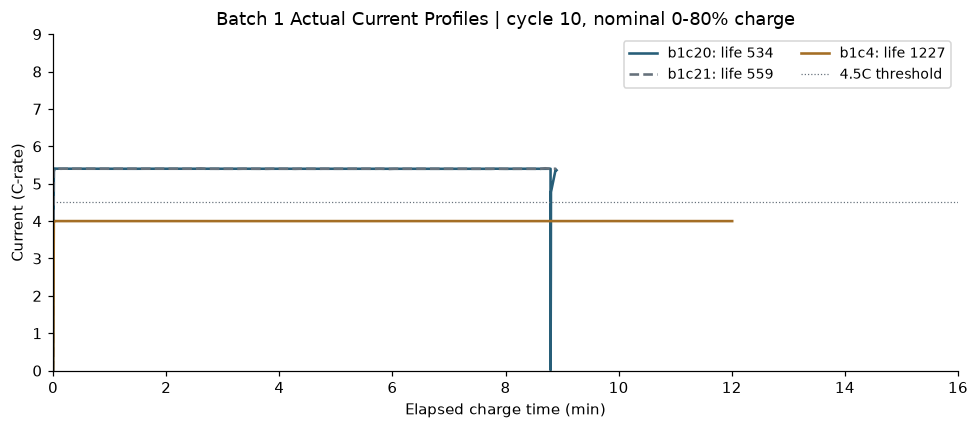

In [48]:
plot_current_patterns(1)

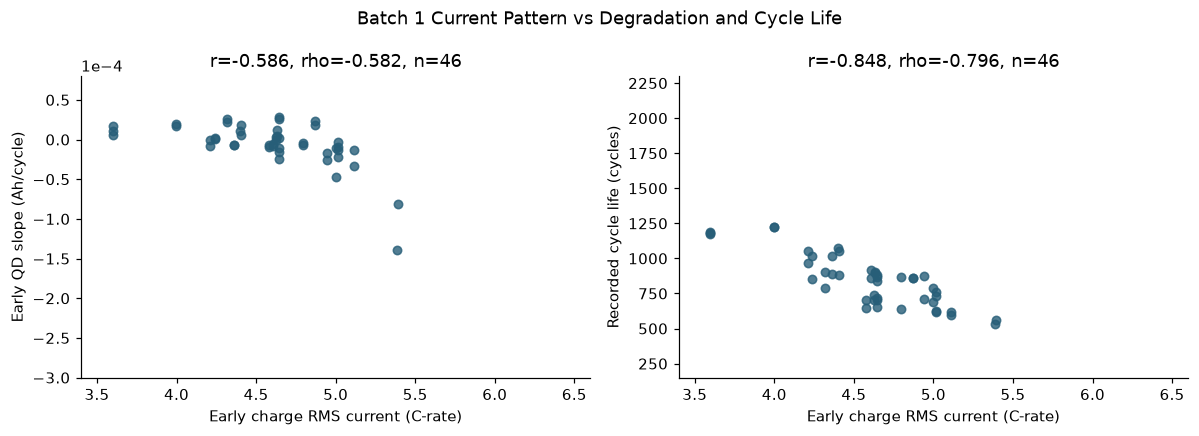

In [49]:
plot_current_degradation(1)

RMS 전류–수명 r=−0.848, 초기 QD 기울기 r=−0.586입니다. 큰 RMS 전류와 더 빠른 초기 용량 감소가 함께 나타나지만 충전 시간·정책도 같이 달라집니다. 실측 전류를 단독 원인으로 해석하기보다 조건 맥락과 열화 신호를 결합합니다.

### 실제 전류 파형 및 열화 연관성 · Batch 2

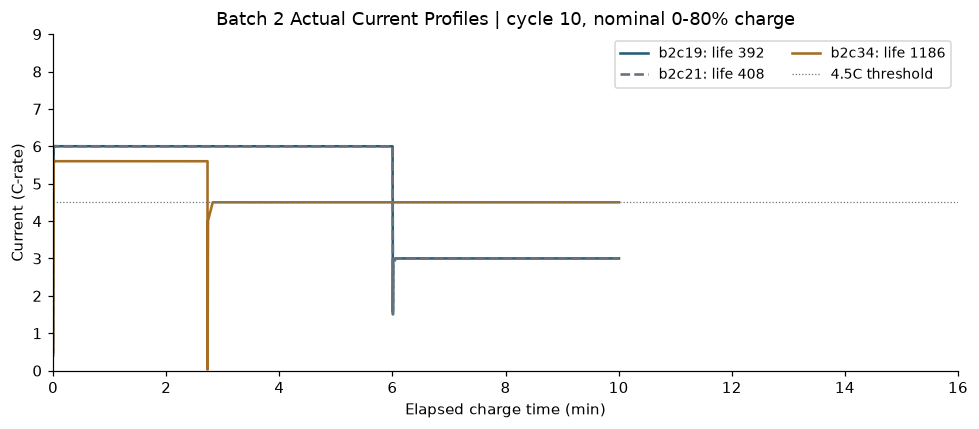

In [50]:
plot_current_patterns(2)

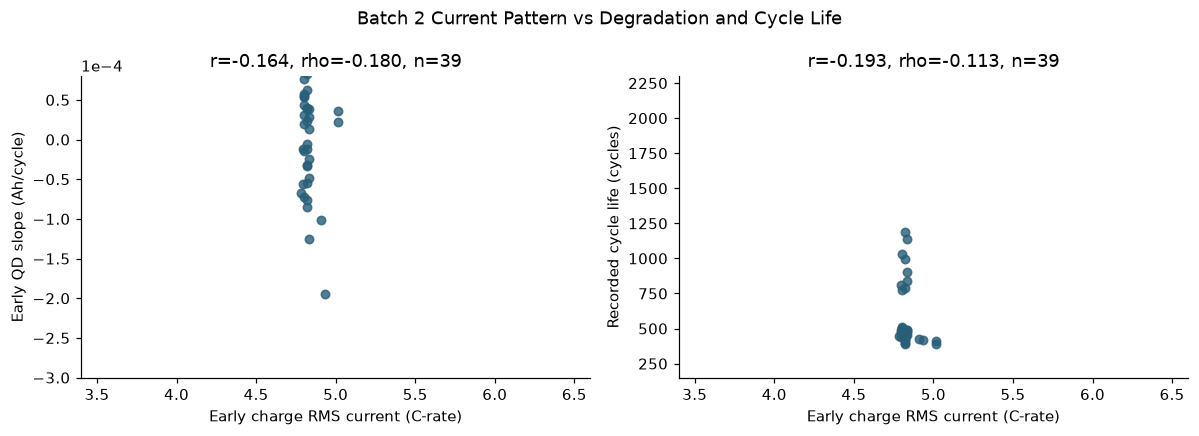

In [51]:
plot_current_degradation(2)

RMS 전류–수명 r=−0.193, 초기 QD 기울기 r=−0.164입니다. 평균 전류는 약4.8C로 비슷한 반면 단계 구조는 달라집니다. 동일 평균 충전 시간의 프로토콜도 같은 수명 조건은 아니며, 실제 RMS·변동계수로 이를 구분합니다.

### 실제 전류 파형 및 열화 연관성 · Batch 3

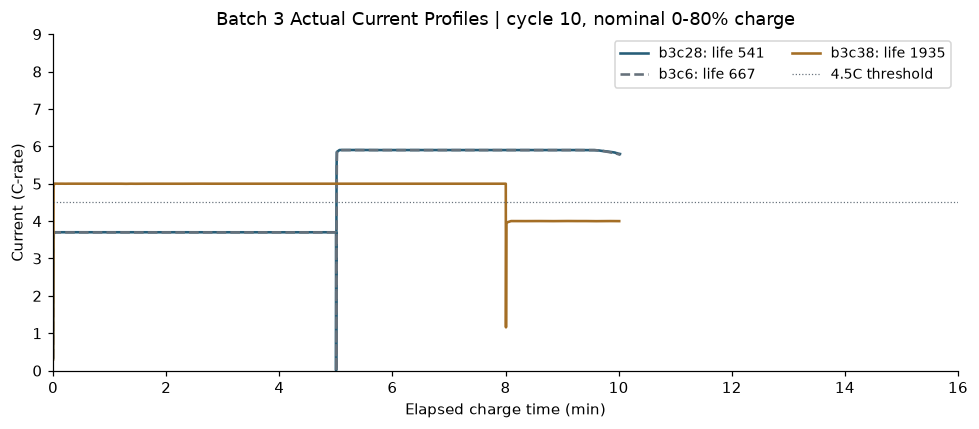

In [52]:
plot_current_patterns(3)

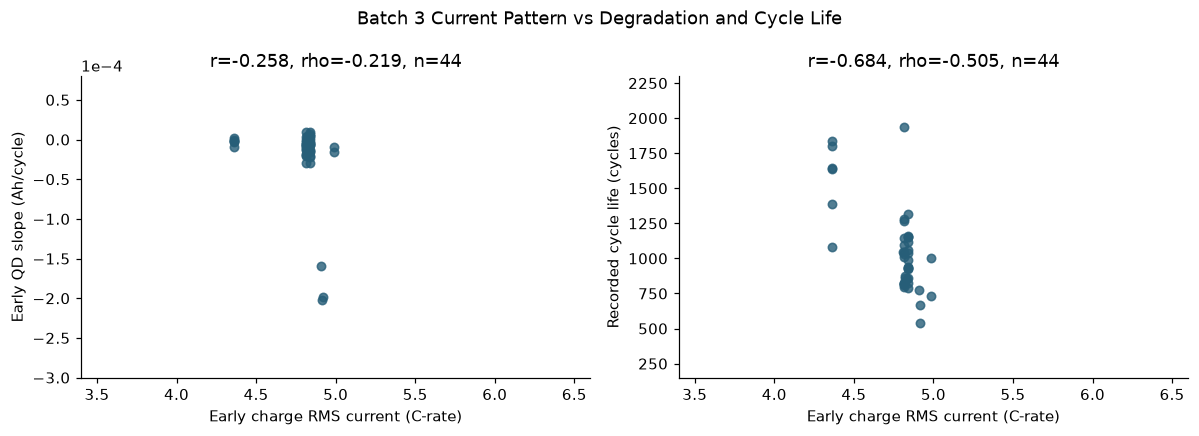

In [53]:
plot_current_degradation(3)

RMS 전류–수명 r=−0.684, 초기 QD 기울기 r=−0.258입니다. 전류 변동계수–초기 QD 기울기는 r=−0.511입니다. 평균 속도 하나보다 단계 변화가 유용한 보완 신호지만 배치마다 관계 크기가 달라 그룹 검증이 필요합니다.

### 실제 전류 분석의 설계 시사점

RMS 전류와 수명의 연관은 배치1/3에서 비교적 크고 배치2에서는 약합니다. 파형을 직접 사용해도 관계가 자동으로 모든 조건에 일반화하지는 않습니다. 평균 전류와0–80% 충전 시간의 |r|는 세 배치 모두0.99 이상이라 두 변수를 동시에 넣는 것보다 대안으로 비교합니다. RMS 전류·변동계수는 추가 후보로 정의하고 정책 그룹 분리와 외부 배치 안정성을 선정 기준으로 사용합니다.

전류 제곱 적분은 전류 크기를 반영하는 기술적 지표입니다. 저항·방열 조건을 반영한 실제 발열량과 구분합니다.

### 배치 비교 및 모델 설계 시사점

**충전 속도 하나로 수명을 설명하기 어렵습니다.** C1–수명 r은 Batch 1 −0.580, Batch 2 +0.191, Batch 3 −0.083입니다. Batch 1도 EOL 근처 집단에서는 −0.206으로 약해집니다. 이 관계는 충전 단계·전환 SOC·온도·종료 이력의 맥락과 함께 해석해야 합니다.

**큰 Pearson 계수의 모양을 확인해야 합니다.** Batch 3의 C1–초기 기울기 Pearson +0.718과 Spearman −0.093은 다른 관점을 보여줍니다. 큰 선형 계수만으로 고속 충전이 열화를 완화한다고 결론 내리지 않고 극단값과 순위 관계를 함께 확인합니다.

**정책 평균보다 새로운 정책의 적용 가능성이 기업의 검증 질문입니다.** 정책별 반복 표본이 작고 Batch 2의 8개 정책은 타깃이 전부 결측입니다. 관측 평균의 순위보다 본 적 없는 정책에서 신뢰할 수 있는지가 핵심입니다. C1·SOC·C2를 분해하고 정책 그룹 단위 검증을 선정했습니다.

## 5. 초기 피처의 수명 상관 및 중복성 분석

**원래 질문:** 어떤 신호가 수명과 연관되는가?

**구체화한 질문:** 초기 피처의 수명 상관이 배치와 분석 대상에 따라 달라지는가? 서로 중복되는 피처는 무엇이며 어떤 조합을 모델 후보로 둘 근거가 있는가?

기존 IR 단독 탐색을 이 질문에 통합했습니다. 초기 평균·변화량·기울기와 ΔQ 통계량을 셀 단위로 연결합니다.

In [54]:
# 실습 설정: 충전 시간 품질 기준. 산업 승인 기준이 아닙니다.
CHARGE_TIME_MAX_MIN = 60

def positive_mean(values, upper=None):
    values = np.asarray(values, dtype=float)
    keep = np.isfinite(values) & (values > 0)
    if upper is not None: keep &= values <= upper
    return float(values[keep].mean()) if keep.any() else np.nan

early_rows = []
for cell_id, group in df.groupby("cell_id", sort=False):
    early = group[group.cycle.between(EARLY_START, EARLY_END)]
    q2 = group.loc[group.cycle == 2, "QD"]
    first_ir = group.loc[group.cycle.between(2, 10), "IR"]
    last_ir = group.loc[group.cycle.between(91, 100), "IR"]
    early_rows.append({"cell_id": cell_id,
        "QD_cycle2": float(q2.iloc[0]) if len(q2) else np.nan,
        "mean_IR": positive_mean(early.IR),
        "delta_IR": positive_mean(last_ir) - positive_mean(first_ir),
        "mean_Tavg": positive_mean(early.Tavg), "mean_Tmax": positive_mean(early.Tmax),
        "mean_chargetime": positive_mean(early.chargetime, upper=CHARGE_TIME_MAX_MIN)})
early_features = pd.DataFrame(early_rows)
features = cells_charge.merge(early_features, on="cell_id", validate="one_to_one")
FEATURE_COLUMNS = ["logvar_deltaQ", "min_deltaQ", "mean_deltaQ", "QD_cycle2", "slope_QD",
    "mean_IR", "delta_IR", "mean_Tavg", "mean_Tmax", "mean_chargetime", "C1", "SOC_switch", "C2"] + CURRENT_INPUT_FIELDS
assert features.cell_id.is_unique

def feature_correlations(data, cohort):
    rows = []
    for batch_no, group in select_cohort(data, cohort).groupby("batch"):
        for feature in FEATURE_COLUMNS:
            rows.append({"cohort": cohort, "batch": batch_no, "feature": feature, **pair_stats(group, feature, "cycle_life")})
    return pd.DataFrame(rows)
feature_corr = pd.concat([feature_correlations(features, c) for c in ["all_targets", "eol_near"]], ignore_index=True)
display(feature_corr[feature_corr.feature.isin(["logvar_deltaQ", "mean_IR", "mean_chargetime"])].round(3))

,cohort,batch,feature,n,pearson,spearman
0,all_targets,1,logvar_deltaQ,46,-0.886,-0.871
5,all_targets,1,mean_IR,46,0.218,0.189
9,all_targets,1,mean_chargetime,46,0.739,0.619
17,all_targets,2,logvar_deltaQ,39,-0.902,-0.709
22,all_targets,2,mean_IR,33,-0.626,-0.199
26,all_targets,2,mean_chargetime,39,-0.917,-0.756
34,all_targets,3,logvar_deltaQ,44,-0.702,-0.797
39,all_targets,3,mean_IR,44,0.190,0.169
43,all_targets,3,mean_chargetime,44,0.637,0.192
51,eol_near,1,logvar_deltaQ,33,-0.831,-0.841


In [55]:
# 실습 설정: 피처 중복 행렬의 분석 대상
FEATURE_COHORT='eol_near'
labels=['Log Var DQ','Min DQ','Mean DQ','QD2','QD slope','IR avg','IR change','T avg','T max','Charge time','C1','Switch SOC','C2','Current mean','Current RMS','Current CV','High-current share']
def plot_feature_life(batch_no):
    fig,ax=plt.subplots(figsize=(9,6.3))
    y=np.arange(len(FEATURE_COLUMNS))
    for cohort,offset,color,hatch in [('all_targets',-.18,BLUE,None),('eol_near',.18,GOLD,'//')]:
        group=feature_corr[(feature_corr.batch==batch_no)&(feature_corr.cohort==cohort)].set_index('feature').reindex(FEATURE_COLUMNS)
        ax.barh(y+offset,group.pearson,height=.34,color=color,hatch=hatch,label=cohort)
    ax.axvline(0,color=GRAY,linewidth=.8)
    ax.set_yticks(y,labels)
    ax.invert_yaxis()
    ax.set(title=f'Batch {batch_no} Early-Cycle Feature Correlations with Cycle Life',xlabel='Pearson r',xlim=(-1,1))
    ax.legend(fontsize=8,loc='lower right')
    show_and_save(f'q5_feature_life_b{batch_no}')
    display(feature_corr[feature_corr.batch==batch_no][['cohort','feature','n','pearson','spearman']].round(3))

### 초기 피처의 수명 상관 분석 · Batch 1

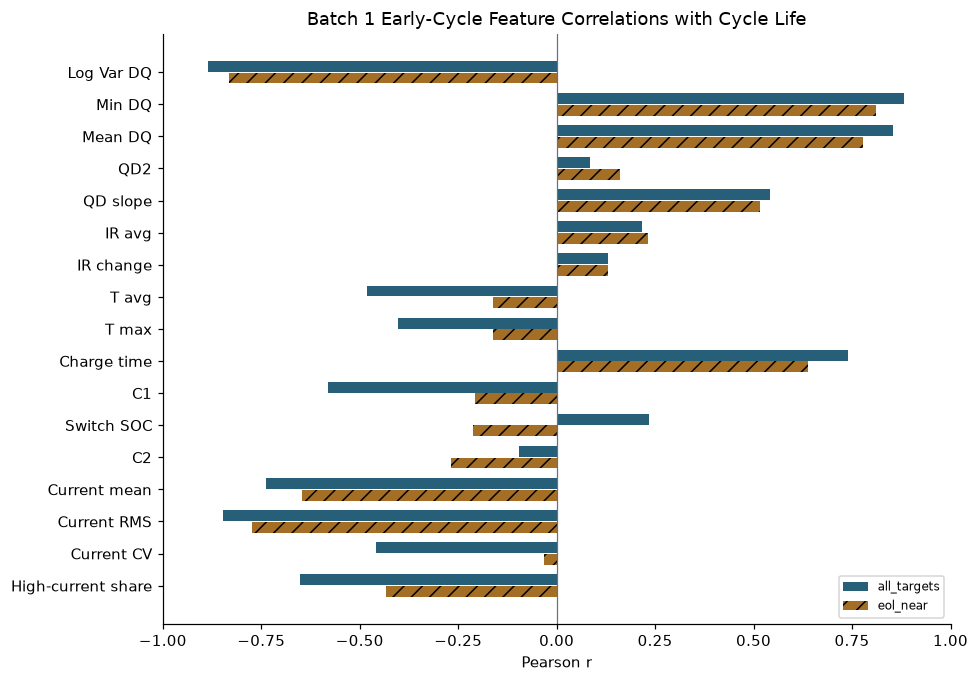

,cohort,feature,n,pearson,spearman
0,all_targets,logvar_deltaQ,46,-0.886,-0.871
1,all_targets,min_deltaQ,46,0.882,0.850
2,all_targets,mean_deltaQ,46,0.854,0.828
3,all_targets,QD_cycle2,46,0.086,0.080
4,all_targets,slope_QD,46,0.541,0.580
5,all_targets,mean_IR,46,0.218,0.189
6,all_targets,delta_IR,46,0.130,-0.226
7,all_targets,mean_Tavg,46,-0.482,-0.371
8,all_targets,mean_Tmax,46,-0.404,-0.323
9,all_targets,mean_chargetime,46,0.739,0.619


In [56]:
plot_feature_life(1)

Batch 1의 ΔQ 신호는 두 집단에서 음의 연관을 보입니다. C1·온도 등의 관계는 대상 선택에 따라 달라지므로 큰 계수만으로 집단을 고르지 않습니다.

### 초기 피처의 수명 상관 분석 · Batch 2

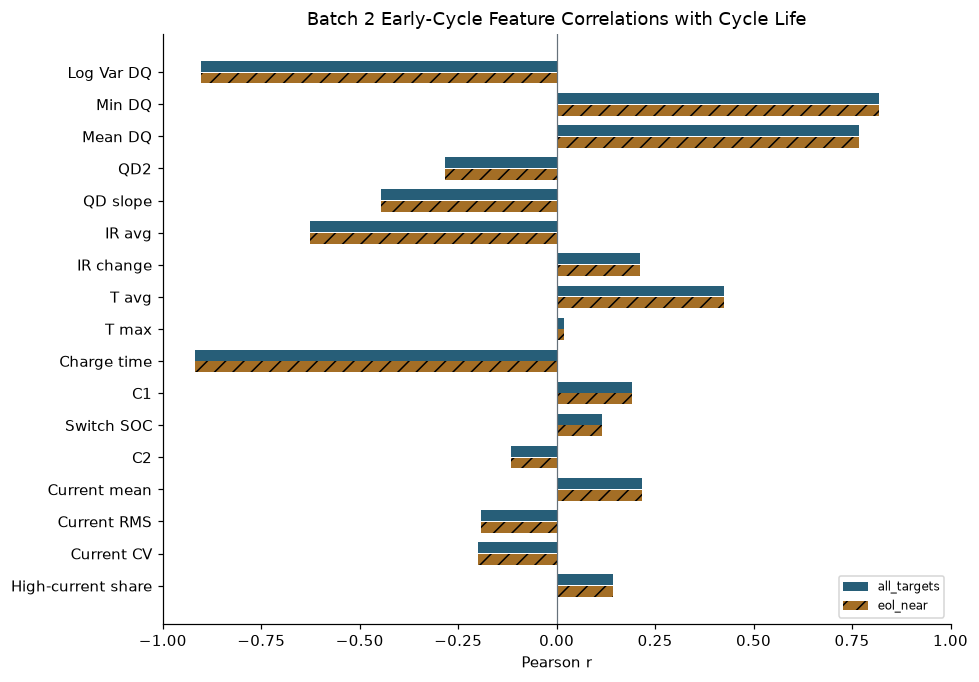

,cohort,feature,n,pearson,spearman
17,all_targets,logvar_deltaQ,39,-0.902,-0.709
18,all_targets,min_deltaQ,39,0.819,0.661
19,all_targets,mean_deltaQ,39,0.767,0.697
20,all_targets,QD_cycle2,39,-0.284,0.085
21,all_targets,slope_QD,39,-0.445,-0.271
22,all_targets,mean_IR,33,-0.626,-0.199
23,all_targets,delta_IR,33,0.211,0.282
24,all_targets,mean_Tavg,39,0.425,0.166
25,all_targets,mean_Tmax,39,0.019,-0.136
26,all_targets,mean_chargetime,39,-0.917,-0.756


In [57]:
plot_feature_life(2)

Batch 2에서는 충전 시간이 가장 강한 절대 상관입니다. IR 평균은 변수별 표본 수가 33으로 줄어드는 점을 함께 확인합니다.

### 초기 피처의 수명 상관 분석 · Batch 3

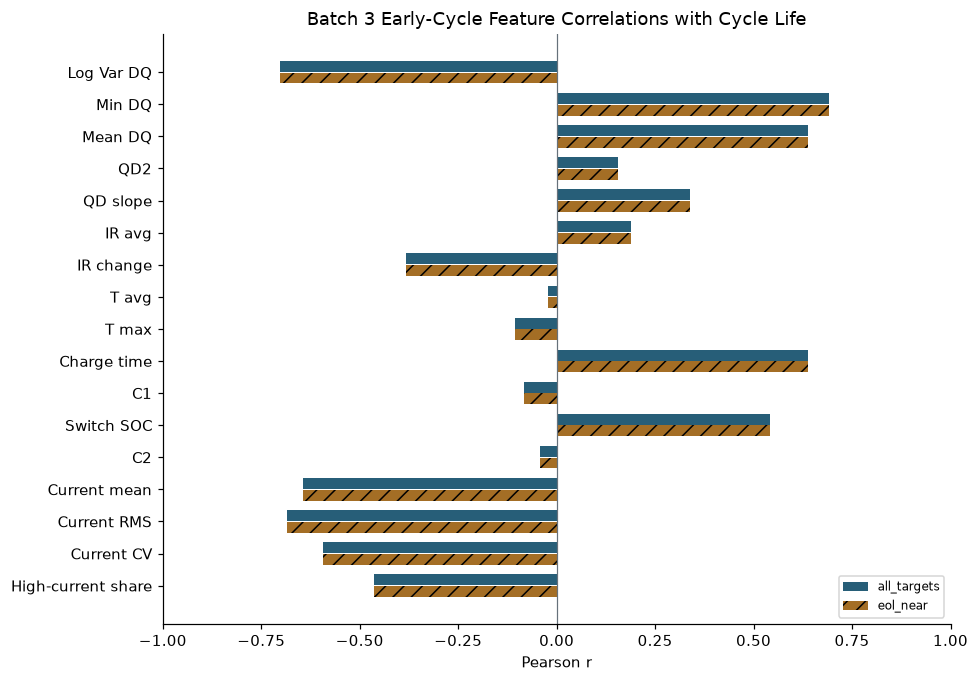

,cohort,feature,n,pearson,spearman
34,all_targets,logvar_deltaQ,44,-0.702,-0.797
35,all_targets,min_deltaQ,44,0.692,0.776
36,all_targets,mean_deltaQ,44,0.639,0.756
37,all_targets,QD_cycle2,44,0.155,0.128
38,all_targets,slope_QD,44,0.338,0.088
39,all_targets,mean_IR,44,0.190,0.169
40,all_targets,delta_IR,44,-0.383,-0.231
41,all_targets,mean_Tavg,44,-0.022,0.025
42,all_targets,mean_Tmax,44,-0.106,-0.035
43,all_targets,mean_chargetime,44,0.637,0.192


In [58]:
plot_feature_life(3)

Batch 3에서는 ΔQ 로그 분산의 음의 연관과 충전 시간의 양의 연관이 보입니다. C1 단독 관계는 약해 운전 맥락을 함께 고려합니다.

In [59]:
def plot_feature_matrix(batch_no):
    group=select_cohort(features,FEATURE_COHORT)
    group=group[group.batch==batch_no]
    matrix = group[FEATURE_COLUMNS + ["cycle_life"]].corr()
    short_labels = labels + ["Life"]
    fig, ax = plt.subplots(figsize=(11, 10))
    image = ax.imshow(matrix, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(matrix)), short_labels, rotation=60, ha="right", fontsize=11)
    ax.set_yticks(range(len(matrix)), short_labels, fontsize=11)
    for row in range(len(matrix)):
        for col in range(len(matrix)):
            value = matrix.iloc[row, col]
            ax.text(col, row, f"{value:.2f}" if abs(value)>=.8 and row!=col else "", ha="center", va="center", fontsize=10,
                    color="white" if abs(value) > .65 else "black")
    fig.colorbar(image, ax=ax, shrink=.8, label="Pearson r")
    ax.set_title(f"Batch {batch_no} Feature Correlation Structure | {FEATURE_COHORT} | n={len(group)}")
    show_and_save(f"q5_feature_matrix_b{batch_no}")

### 피처 간 상관구조 및 중복성 · Batch 1

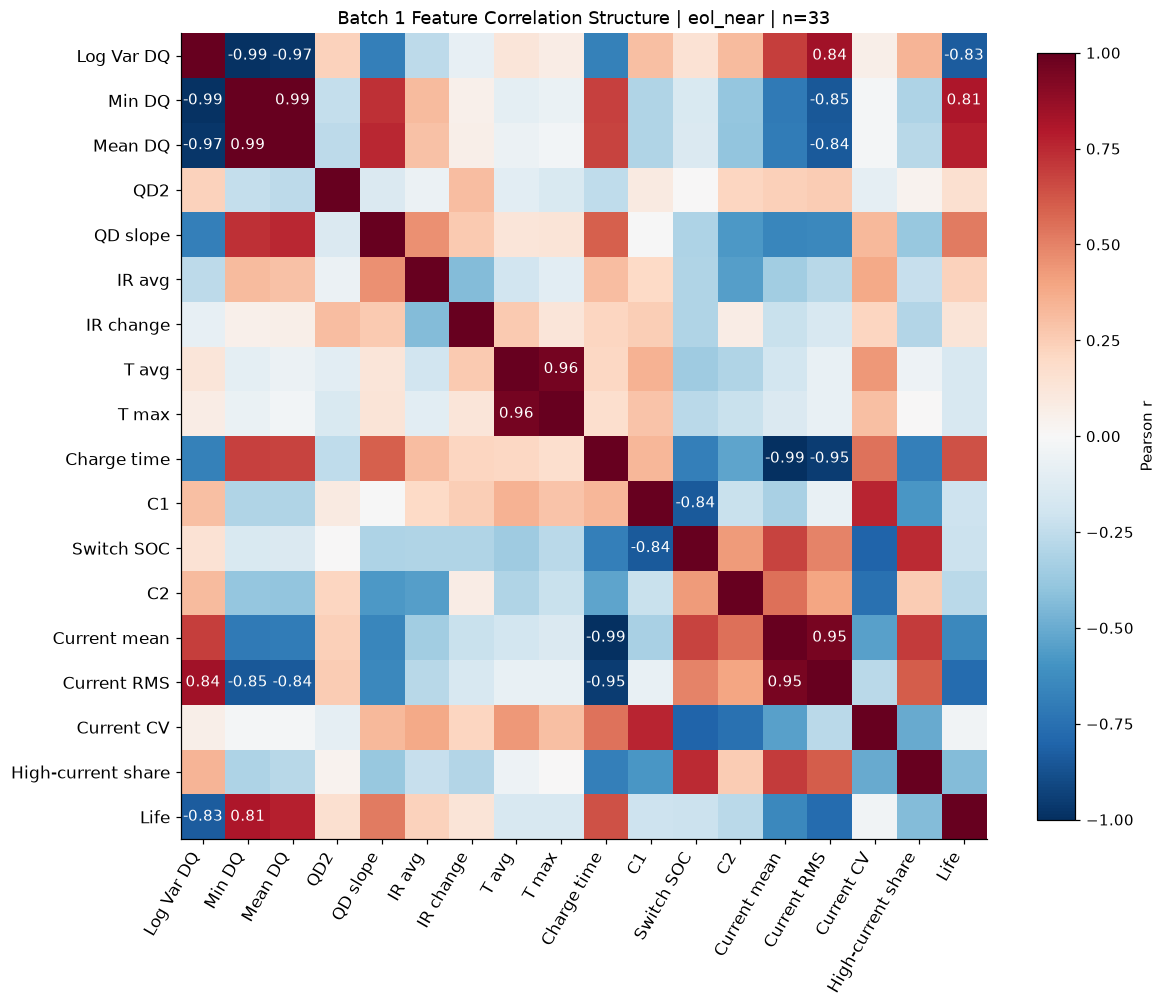

In [60]:
plot_feature_matrix(1)

ΔQ 통계량과 온도 변수의 중복을 같은 배치 안에서 확인합니다. 높은 중복은 변수 추가의 독립 기여가 확인됐다는 뜻이 아닙니다.

### 피처 간 상관구조 및 중복성 · Batch 2

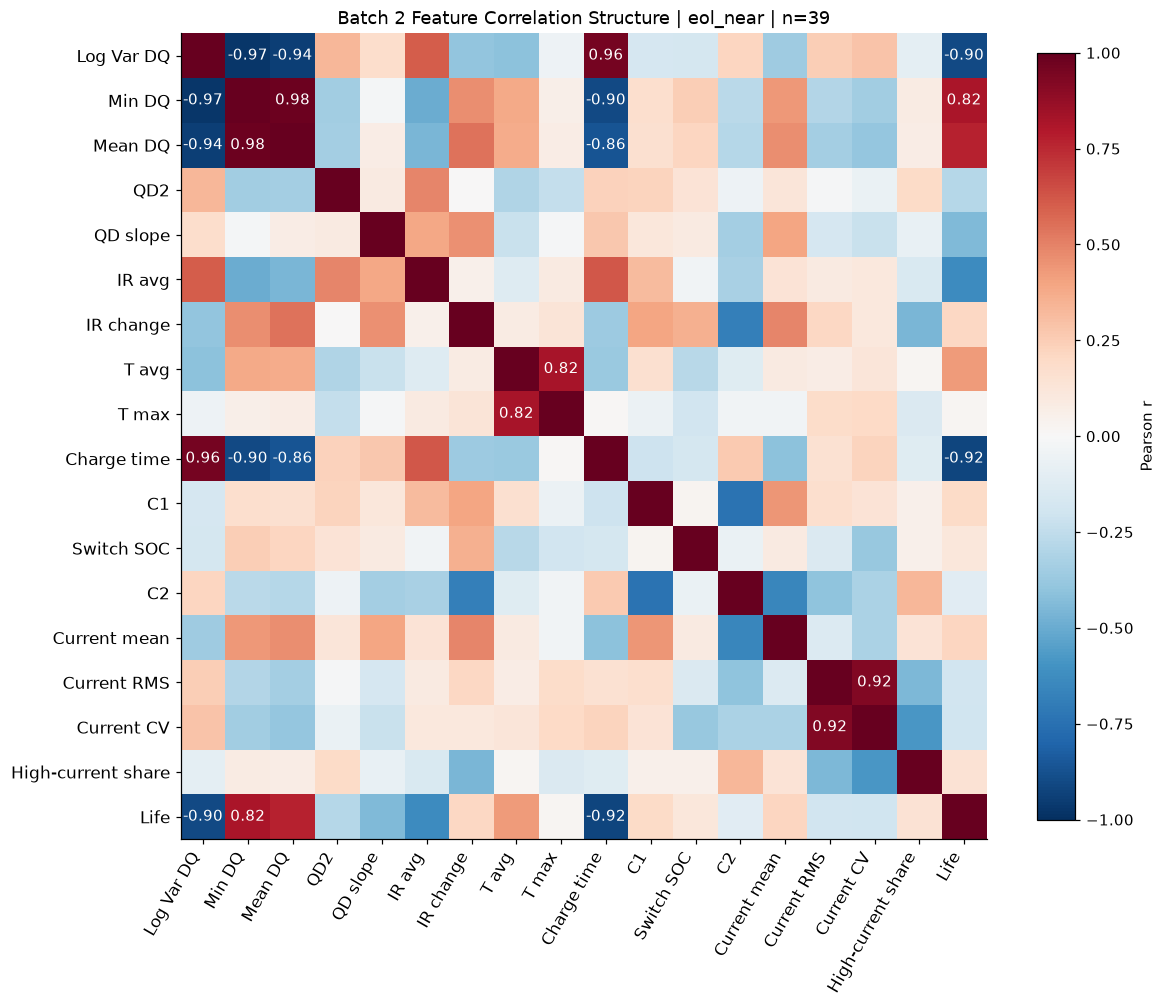

In [61]:
plot_feature_matrix(2)

ΔQ 통계량과 온도 변수의 중복을 같은 배치 안에서 확인합니다. 높은 중복은 변수 추가의 독립 기여가 확인됐다는 뜻이 아닙니다.

### 피처 간 상관구조 및 중복성 · Batch 3

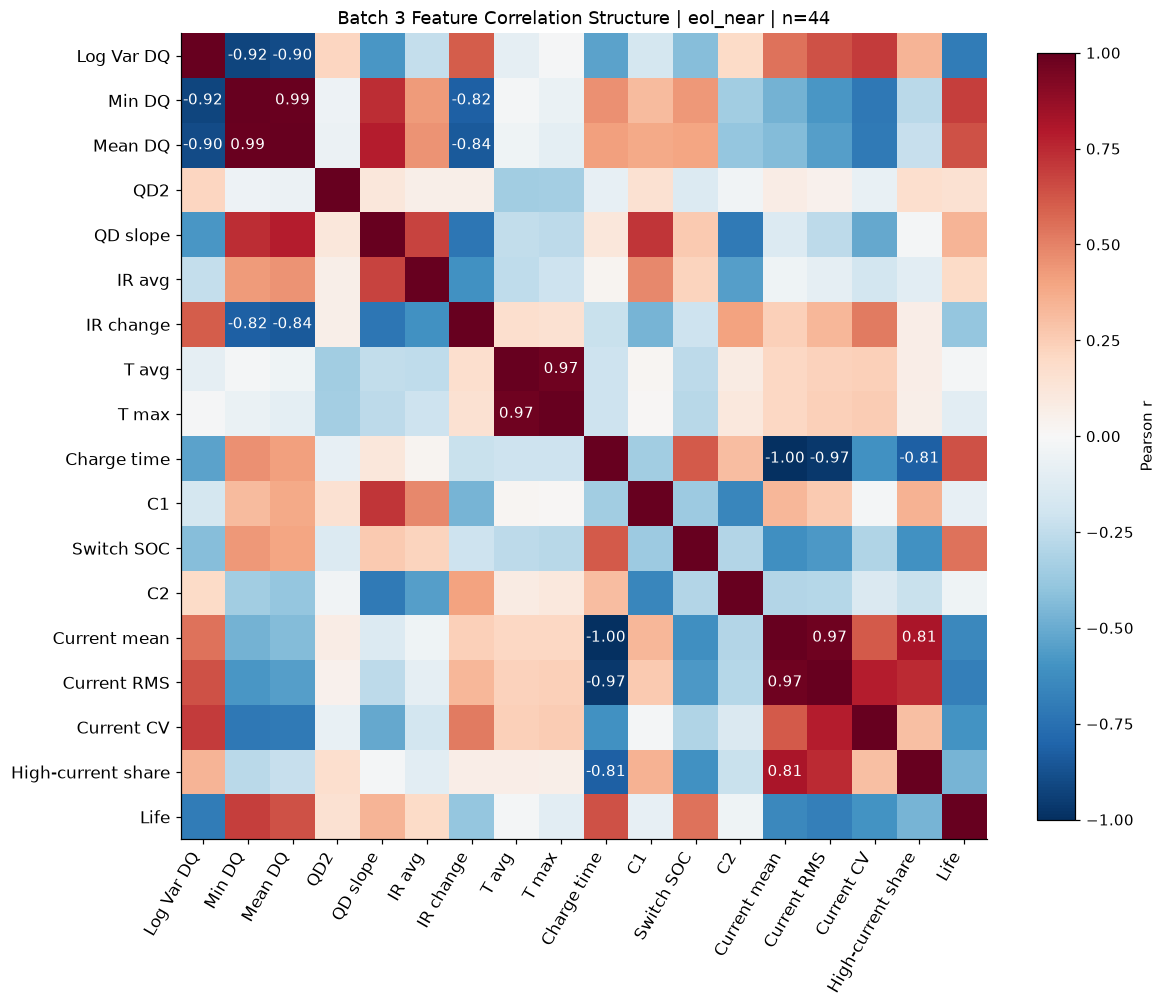

In [62]:
plot_feature_matrix(3)

ΔQ 통계량과 온도 변수의 중복을 같은 배치 안에서 확인합니다. 높은 중복은 변수 추가의 독립 기여가 확인됐다는 뜻이 아닙니다.

In [63]:
redundancy_rows = []
for cohort in ["all_targets", "eol_near"]:
    for batch_no, group in select_cohort(features, cohort).groupby("batch"):
        for feature1, feature2 in [("logvar_deltaQ", "min_deltaQ"), ("min_deltaQ", "mean_deltaQ"), ("mean_Tavg", "mean_Tmax"), ("current_rms_C", "mean_chargetime"), ("current_mean_C", "mean_chargetime"), ("current_rms_C", "current_cv"), ("current_cv", "SOC_switch")]:
            redundancy_rows.append({"cohort": cohort, "batch": batch_no, "feature1": feature1,
                                   "feature2": feature2, **pair_stats(group, feature1, feature2)})
redundancy = pd.DataFrame(redundancy_rows)
display(redundancy.round(3))
rank = feature_corr[feature_corr.cohort == "all_targets"].copy()
rank["abs_r"] = rank.pearson.abs()
display(rank.sort_values("abs_r", ascending=False).groupby("batch").head(3).sort_values(["batch", "abs_r"], ascending=[True, False]).round(3))
print("mean_IR의 전체 타깃 표본 수:")
display(feature_corr[(feature_corr.cohort == "all_targets") & (feature_corr.feature == "mean_IR")][["batch", "n", "pearson", "spearman"]])

,cohort,batch,feature1,feature2,n,pearson,spearman
0,all_targets,1,logvar_deltaQ,min_deltaQ,46,-0.947,-0.987
1,all_targets,1,min_deltaQ,mean_deltaQ,46,0.993,0.989
2,all_targets,1,mean_Tavg,mean_Tmax,46,0.956,0.951
3,all_targets,1,current_rms_C,mean_chargetime,46,-0.967,-0.919
4,all_targets,1,current_mean_C,mean_chargetime,46,-0.993,-0.995
5,all_targets,1,current_rms_C,current_cv,46,0.265,0.170
6,all_targets,1,current_cv,SOC_switch,46,-0.833,-0.759
7,all_targets,2,logvar_deltaQ,min_deltaQ,39,-0.975,-0.985
8,all_targets,2,min_deltaQ,mean_deltaQ,39,0.979,0.950
9,all_targets,2,mean_Tavg,mean_Tmax,39,0.825,0.792


,cohort,batch,feature,n,pearson,spearman,abs_r
0,all_targets,1,logvar_deltaQ,46,-0.886,-0.871,0.886
1,all_targets,1,min_deltaQ,46,0.882,0.850,0.882
2,all_targets,1,mean_deltaQ,46,0.854,0.828,0.854
26,all_targets,2,mean_chargetime,39,-0.917,-0.756,0.917
17,all_targets,2,logvar_deltaQ,39,-0.902,-0.709,0.902
18,all_targets,2,min_deltaQ,39,0.819,0.661,0.819
34,all_targets,3,logvar_deltaQ,44,-0.702,-0.797,0.702
35,all_targets,3,min_deltaQ,44,0.692,0.776,0.692
48,all_targets,3,current_rms_C,44,-0.684,-0.505,0.684


mean_IR의 전체 타깃 표본 수:


,batch,n,pearson,spearman
5,1,46,0.217968,0.189034
22,2,33,-0.625513,-0.199215
39,3,44,0.189851,0.168652


In [64]:
# 전체 상관과 배치 내 관계를 구분하는 기술적 EDA입니다.
# 동일한 유효 타깃 집단에서 변수별 결측 쌍을 제외합니다.
aggregation_rows=[]
for feature in ['QD_cycle2','logvar_deltaQ','mean_chargetime']:
    pair=select_cohort(features,'all_targets')[['batch',feature,'cycle_life']].dropna()
    centered_x=pair[feature]-pair.groupby('batch')[feature].transform('mean')
    centered_y=pair.cycle_life-pair.groupby('batch').cycle_life.transform('mean')
    row={'feature':feature,'pair_n':len(pair),'pooled_r':pair[feature].corr(pair.cycle_life),
         'batch_mean_centered_r':centered_x.corr(centered_y)}
    for batch_no,group in pair.groupby('batch'):
        row[f'b{batch_no}_r']=group[feature].corr(group.cycle_life)
    aggregation_rows.append(row)
aggregation_diagnostics=pd.DataFrame(aggregation_rows)
display(aggregation_diagnostics.round(3))
initial_state_summary=select_cohort(features,'all_targets').groupby('batch').agg(
    median_QD2=('QD_cycle2','median'),median_life=('cycle_life','median'),
    median_charge_time=('mean_chargetime','median'),min_charge_time=('mean_chargetime','min'),max_charge_time=('mean_chargetime','max'))
display(initial_state_summary.round(4))

,feature,pair_n,pooled_r,batch_mean_centered_r,b1_r,b2_r,b3_r
0,QD_cycle2,129,-0.525,-0.013,0.086,-0.284,0.155
1,logvar_deltaQ,129,-0.851,-0.773,-0.886,-0.902,-0.702
2,mean_chargetime,129,0.311,0.439,0.739,-0.917,0.637


,median_QD2,median_life,median_charge_time,min_charge_time,max_charge_time
batch,,,,,
1,1.0787,858.5,10.9957,8.9873,13.3842
2,1.0954,472.0,10.1735,10.0358,10.2384
3,1.0653,1005.5,10.0433,10.0412,11.0407


### 최단 수명 셀 통합 진단

1절에서 식별한 최단 셀을 ΔQ·초기 QD·IR·온도·실제 전류와 연결합니다. 배치 내 나머지 유효 타깃 셀의 중앙값·상대 순위, 동일 정책 셀의 관측값을 기준으로 비교합니다. 상대 순위는 비교 셀 중 해당 값 이하인 비율이며 고장 확률이 아닙니다. 후반 knee는 전체 수명 궤적을 설명하는 반응 지표입니다.

In [65]:
CASE_FEATURES=['logvar_deltaQ','QD_cycle2','slope_QD','mean_IR','delta_IR','mean_Tavg','mean_Tmax',
               'mean_chargetime','current_rms_C','current_cv']
case_rows,case_peer_rows=[],[]
for batch_no,group in select_cohort(features,'all_targets').groupby('batch'):
    target=group.loc[group.cycle_life.idxmin()]
    others=group[group.cell_id!=target.cell_id]
    peers=others[others.charging_policy==target.charging_policy]
    for row in peers.itertuples():
        case_peer_rows.append({'batch':batch_no,'case_id':target.cell_id,'peer_id':row.cell_id,
                               'peer_life':row.cycle_life,'life_gap':row.cycle_life-target.cycle_life,
                               'charging_policy':row.charging_policy})
    for feature in CASE_FEATURES:
        reference=others[feature].replace([np.inf,-np.inf],np.nan).dropna()
        value=target[feature]
        case_rows.append({'batch':batch_no,'cell_id':target.cell_id,'cycle_life':target.cycle_life,
                          'feature':feature,'case_value':value,'batch_other_median':reference.median(),
                          'reference_n':len(reference),
                          'rank_percentile':100*(reference<=value).mean() if np.isfinite(value) and len(reference) else np.nan,
                          'same_policy_peer_n':int(peers[feature].notna().sum()),
                          'same_policy_peer_median':peers[feature].median()})
shortest_diagnostics=pd.DataFrame(case_rows)
shortest_policy_peers=pd.DataFrame(case_peer_rows)
case_knees=shortest[['cell_id','batch','cycle_life']].merge(knee_analysis[['cell_id','knee_cycle','slope_before','slope_after']],on='cell_id',validate='one_to_one')

def plot_shortest_diagnostics(batch_no):
    group=select_cohort(features,'all_targets');group=group[group.batch==batch_no]
    target=group.loc[group.cycle_life.idxmin()]
    others=group[group.cell_id!=target.cell_id]
    peers=others[others.charging_policy==target.charging_policy]
    fig,axes=plt.subplots(1,2,figsize=(11,4))
    for ax in axes:ax.grid(alpha=.15)
    for row,color,ls in [(target,BLUE,'-')]+[(r,GRAY,'--') for _,r in peers.iterrows()]:
        sg=df[(df.cell_id==row.cell_id)&df.cycle.between(2,100)&df.QD.between(.01,QD_UPPER_AH)]
        axes[0].plot(sg.cycle,sg.QD,color=color,ls=ls,lw=1.6,label=f'{row.cell_id} ({row.cycle_life:.0f})')
        curve=curve_records[row.cell_id]
        axes[1].plot(curve['V'],curve['delta'],color=color,ls=ls,lw=1.6,label=row.cell_id)
    ref=df[df.cell_id.isin(others.cell_id)&df.cycle.between(2,100)&df.QD.between(.01,QD_UPPER_AH)].groupby('cycle').QD.median()
    axes[0].plot(ref.index,ref.values,color=GOLD,lw=2,label='Other-cell median')
    curves=np.vstack([curve_records[cid]['delta'] for cid in others.cell_id])
    axes[1].plot(curve_records[target.cell_id]['V'],np.median(curves,axis=0),color=GOLD,lw=2,label='Other-cell median')
    axes[0].set(xlim=(2,100),ylim=(1.02,1.13),xlabel='Cycle',ylabel='Discharge capacity QD (Ah)',title='Early capacity vs same-policy peers')
    axes[1].set(xlim=(2,3.5),ylim=(-.08,.015),xlabel='Voltage (V)',ylabel='Q100(V)-Q10(V) (Ah)',title='Early curve change vs same-policy peers')
    for ax in axes:ax.legend(fontsize=8,loc='lower left')
    fig.suptitle(f'Batch {batch_no} Shortest-Life Cell {target.cell_id} | life {target.cycle_life:.0f}',fontsize=12)
    show_and_save(f'q1_shortest_diagnostics_b{batch_no}')
    display(shortest_diagnostics[shortest_diagnostics.batch==batch_no].round(6))
display(shortest_policy_peers)
display(case_knees.round(6))


,batch,case_id,peer_id,peer_life,life_gap,charging_policy
0,1,b1c20,b1c21,559.0,25.0,5.4C(80%)-5.4C
1,2,b2c19,b2c21,408.0,16.0,6C(60%)-3C
2,3,b3c28,b3c6,667.0,126.0,3.7C(31%)-5.9C-newstructure
3,3,b3c28,b3c21,772.0,231.0,3.7C(31%)-5.9C-newstructure


,cell_id,batch,cycle_life,knee_cycle,slope_before,slope_after
0,b1c20,1,534.0,430.0,-0.000296,-0.000746
1,b2c19,2,392.0,325.0,-0.000256,-0.002362
2,b3c28,3,541.0,385.0,-0.000244,-0.000497


### 최단 수명 셀의 초기 신호 비교 · Batch 1

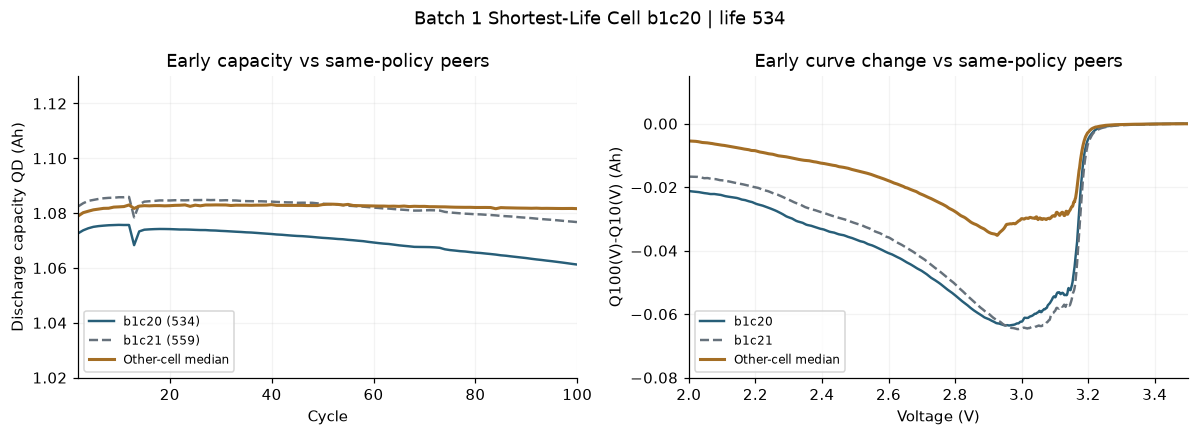

,batch,cell_id,cycle_life,feature,case_value,batch_other_median,reference_n,rank_percentile,same_policy_peer_n,same_policy_peer_median
0,1,b1c20,534.0,logvar_deltaQ,-3.366803,-3.853269,45,97.777778,1,-3.349904
1,1,b1c20,534.0,QD_cycle2,1.072630,1.078961,45,17.777778,1,1.082439
2,1,b1c20,534.0,slope_QD,-0.000140,-0.000003,45,0.000000,1,-0.000082
3,1,b1c20,534.0,mean_IR,0.015210,0.016669,45,2.222222,1,0.015090
4,1,b1c20,534.0,delta_IR,-0.000359,0.000086,45,2.222222,1,-0.000032
5,1,b1c20,534.0,mean_Tavg,32.152922,32.843913,45,33.333333,1,33.136974
6,1,b1c20,534.0,mean_Tmax,34.928347,36.231754,45,24.444444,1,36.948925
7,1,b1c20,534.0,mean_chargetime,9.027208,11.035508,45,2.222222,1,8.987271
8,1,b1c20,534.0,current_rms_C,5.386112,4.630686,45,97.777778,1,5.393182
9,1,b1c20,534.0,current_cv,0.035748,0.260106,45,20.000000,1,0.030296


In [66]:
plot_shortest_diagnostics(1)

**b1c20(534사이클):** 초기 QD 기울기는 −1.40×10⁻⁴ Ah/cycle로 다른45셀보다 가장 음수이고, ΔQ 로그 분산 −3.367은 다른 셀 기준97.8백분위입니다. 같은5.4C 정책의 b1c21도559사이클로 짧습니다. 큰 전류 조건의 공통 단서가 있으나 b1c20의 초기 감소가 더 빠릅니다. 평균 저항과 온도는 높지 않아 “초기 저항/온도가 가장 높은 셀”이라는 설명과는 다릅니다. knee 후보430은 배치 중앙640보다 이릅니다. 초기 열화 변화량과 정책 맥락을 함께 표현해야 합니다.

### 최단 수명 셀의 초기 신호 비교 · Batch 2

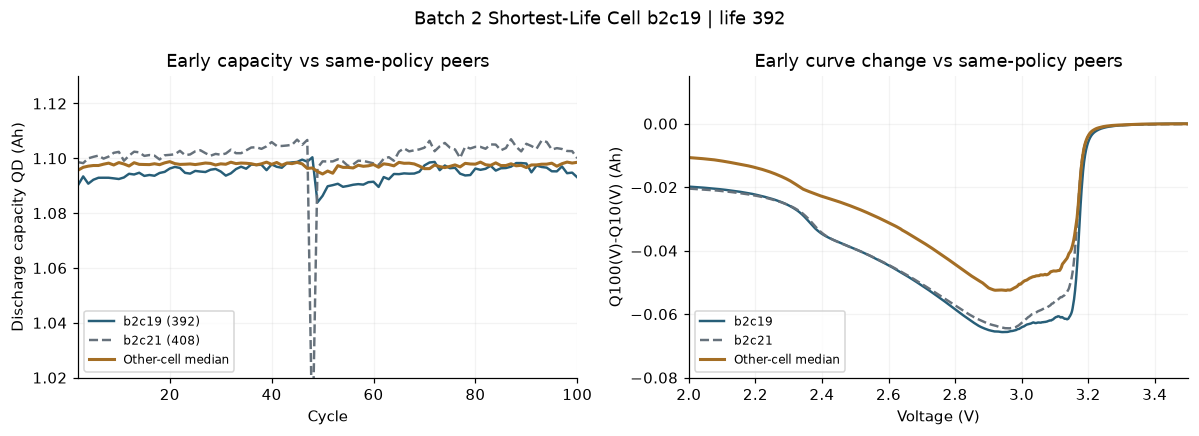

,batch,cell_id,cycle_life,feature,case_value,batch_other_median,reference_n,rank_percentile,same_policy_peer_n,same_policy_peer_median
10,2,b2c19,392.0,logvar_deltaQ,-3.291523,-3.490638,38,81.578947,1,-3.326245
11,2,b2c19,392.0,QD_cycle2,1.090241,1.095677,38,23.684211,1,1.098594
12,2,b2c19,392.0,slope_QD,0.000022,0.000022,38,50.000000,1,0.000035
13,2,b2c19,392.0,mean_IR,0.016718,0.016491,32,62.500000,1,0.017200
14,2,b2c19,392.0,delta_IR,0.000237,-0.000062,32,93.750000,1,0.000213
15,2,b2c19,392.0,mean_Tavg,32.770067,33.030639,38,39.473684,1,33.601188
16,2,b2c19,392.0,mean_Tmax,36.548833,36.426730,38,52.631579,1,38.660766
17,2,b2c19,392.0,mean_chargetime,10.173764,10.173356,38,52.631579,1,10.174732
18,2,b2c19,392.0,current_rms_C,5.017764,4.822410,38,100.000000,1,5.017452
19,2,b2c19,392.0,current_cv,0.307165,0.104590,38,97.368421,1,0.307276


In [67]:
plot_shortest_diagnostics(2)

**b2c19(392사이클):** 초기 QD 기울기는 +2.20×10⁻⁵ Ah/cycle로 배치 중앙 수준이지만 ΔQ 로그 분산은 −3.292(81.6백분위), IR 변화는 +2.37×10⁻⁴(유효 비교32셀 중93.8백분위)입니다. 같은6C(60%)-3C의 b2c21도408사이클이고 IR이 증가합니다. 약10.17분이라는 비슷한 충전 시간 안에서도 RMS 약5.018C와 단계 변화가 존재합니다. 초기 용량이 줄지 않는다고 안전하게 장수명을 판단하기 어려워 ΔQ·저항 변화가 보완 신호가 됩니다. knee 후보325는 배치 중앙370보다 이릅니다.

### 최단 수명 셀의 초기 신호 비교 · Batch 3

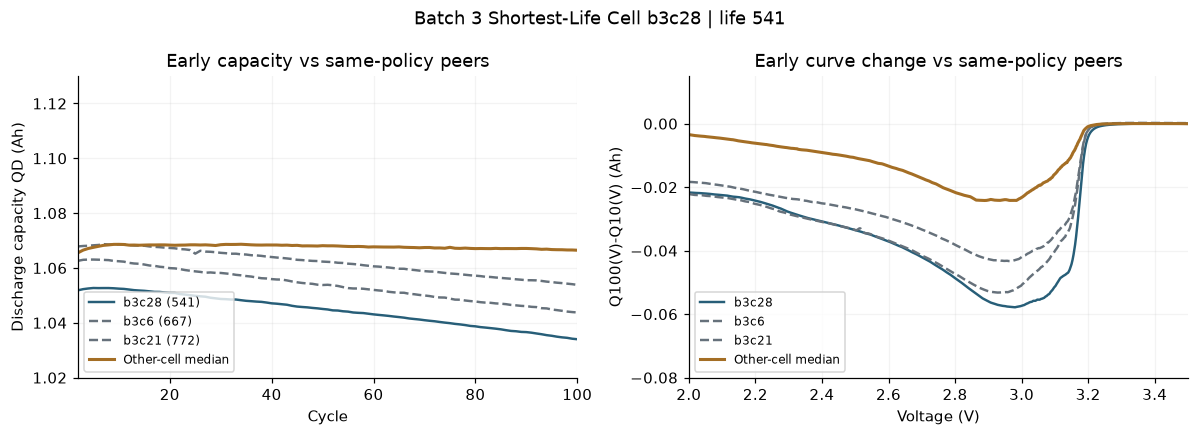

,batch,cell_id,cycle_life,feature,case_value,batch_other_median,reference_n,rank_percentile,same_policy_peer_n,same_policy_peer_median
20,3,b3c28,541.0,logvar_deltaQ,-3.451223,-4.178031,43,100.000000,2,-3.614583
21,3,b3c28,541.0,QD_cycle2,1.051867,1.065558,43,11.627907,2,1.065234
22,3,b3c28,541.0,slope_QD,-0.000198,-0.000007,43,2.325581,2,-0.000181
23,3,b3c28,541.0,mean_IR,0.013421,0.015374,43,0.000000,2,0.013912
24,3,b3c28,541.0,delta_IR,0.000385,-0.000038,43,100.000000,2,0.000233
25,3,b3c28,541.0,mean_Tavg,35.696888,34.107206,43,88.372093,2,34.503802
26,3,b3c28,541.0,mean_Tmax,39.557918,37.233279,43,95.348837,2,37.452714
27,3,b3c28,541.0,mean_chargetime,10.088612,10.043260,43,86.046512,2,10.080042
28,3,b3c28,541.0,current_rms_C,4.917508,4.820014,43,95.348837,2,4.912614
29,3,b3c28,541.0,current_cv,0.229005,0.100204,43,93.023256,2,0.228876


In [68]:
plot_shortest_diagnostics(3)

**b3c28(541사이클):** ΔQ 로그 분산 −3.451과 IR 변화 +3.85×10⁻⁴는 나머지43셀보다 높고, 초기 QD 기울기 −1.98×10⁻⁴는2.3백분위입니다. 초기 Tmax는39.56°C로 나머지 중앙37.23°C보다 높습니다. 같은정책 b3c6/b3c21의 수명667/772와 비교해도 초기 신호가 더 불리합니다. 평균 IR은 오히려 낮아 절대 저항만으로 정렬하는 방식은 위험합니다. knee 후보385는 배치 중앙850보다 빠릅니다. 저항 변화·ΔQ·온도 맥락의 결합이 셀별 차이를 설명하는 후보입니다.

### 통합 진단의 해석 및 의사결정 가치

세 최단 셀의 공통점은 배치 중앙보다 이른 knee 후보지만 초기 신호는 같지 않습니다. Batch2는 초기 QD 증가 중에도 짧게 종료되어 초기 기울기 하나가 수명 위험을 모두 포착하지 못합니다. 배치3은 낮은 절대 IR과 큰 IR 증가가 공존합니다. 정책 평균·절대 상태보다 변화량과 여러 관측 신호의 결합이 셀별 평가의 근거입니다.

동일 정책 비교는 정책 정보를 일부 맞춘 관찰 비교입니다. 반복 셀 수1–2개, 라벨 종료 이력, 측정 채널 및 셀 차이가 남아 있어 특정 열화 메커니즘을 확정하는 인과 실험과 구분합니다. 실제 점검 판단에서는 채널·온도 센서·시험 중단 이력을 먼저 추적합니다.

### 배치 비교 및 모델 설계 시사점

**합친 데이터의 높은 상관이 배치 내 예측 신호를 뜻하지는 않습니다.** QD2–수명 r은 전체 129셀에서 −0.525지만 배치별 평균 중심화 후 −0.013입니다. 배치 내 관계도 약하고 방향이 달라 전체 상관은 배치의 초기 상태·수명 수준 차이를 크게 반영합니다. 초기 용량의 통합 상관만으로 핵심 피처를 선정하기 어렵습니다.

**변화량 신호는 배치 수준 차이를 구분해도 관계가 유지됩니다.** ΔQ 로그 분산–수명 r은 전체 −0.851, 배치 평균 중심화 후 −0.773입니다. 중심화는 각 배치의 평균 차이를 구분하는 기술적 분석이며 다른 운전 조건의 인과 영향을 제거하는 절차는 아닙니다. 이 결과는 QD2보다 ΔQ를 기준 피처로 선정하는 근거입니다.

**최강 상관보다 관계의 적용 범위를 확인합니다.** 충전 시간–수명 r은 +0.739/−0.917/+0.637로 방향이 바뀝니다. Batch 2의 강한 음의 상관을 모든 운전 조건에 적용할 규칙으로 쓰기보다 프로토콜 맥락을 반영하는 후보로 다룹니다.

**피처 수를 늘리는 것과 정보를 늘리는 것은 다릅니다.** ΔQ 통계량끼리 강하게 중복되고 온도 평균·최댓값도 중복됩니다. ΔQ 기본 입력→물리 피처→물리+정책 순으로 비교하고 중복 제거·Ridge 정규화를 구성했습니다. mean_IR의 Batch 2 유효 표본은 33이므로 변수별 분모도 함께 판단합니다.

## 6. 예측 피처 정의 및 모델 설계 전략

| 후보 | 계산 범위·정의 | 설계 근거 |
|---|---|---|
| logvar_deltaQ | 동일 V의 Q100−Q10, `log10(max(var(ddof=1), 1e-15))` | 단일 피처 기본 신호 |
| min_deltaQ / mean_deltaQ | ΔQ의 전압 축 최소·평균 | 높은 수명 상관과 강한 중복을 함께 고려 |
| QD_cycle2 | 실제 cycle 2의 QD | 초기 상태 |
| slope_QD | cycle 2–100 유효 QD의 직선 기울기 | 초기 변화 속도 |
| mean_IR | cycle 2–100 양수·유한 IR 평균 | 저항 신호; 원자료 단위 확인 필요 |
| delta_IR | cycle 91–100 평균−cycle 2–10 평균 | 초기 저항 변화 |
| mean_Tavg / mean_Tmax | cycle 2–100 양수·유한 값 평균 | 운전 조건과 중복 비교 |
| mean_chargetime | cycle 2–100, 0<시간≤60분 평균 | 운전·프로토콜 맥락 |
| current_mean_C / current_rms_C | cycle 2–100 각 0–80% 충전 구간의 시간 가중 평균·RMS를 셀별 평균 | 충전 시간과 중복 비교; RMS 추가 후보 |
| current_cv | 각 충전 구간의 시간 가중 표준편차/평균, 셀별 평균 | 같은 평균 속도의 단계 차이 |
| high_current_charge_fraction | C>4.5 구간의 ∫Cdt / 전체 ∫Cdt, 셀별 평균 | 노출량의 탐색 지표; 문턱값 민감도 확인 |
| C1 / SOC_switch / C2 | 정책 문자열의 첫 속도·전환 SOC·두 번째 속도 | 충전 조건 맥락 |

온도 양수 기준은 이 실험 데이터의 추출 기준입니다. 영하 운전이 가능한 현장에 그대로 적용하지 않습니다. `cycle_life`, 마지막 용량, EOL 근처 플래그, knee 및 후반 기울기는 예측 입력에 넣지 않습니다.

### 후보 모델 목록 및 주력 전략

**주력 후보는 다변량 Ridge 회귀이며, 비교 후보는 복잡도를 제한한 Random Forest 회귀입니다.** 초기100사이클의 관측값으로 총 `cycle_life`를 추정합니다.

| 구분 | 모델 | 입력 및 비교 목적 | EDA 선정 근거 |
|---|---|---|---|
| M0 · 기준 | 학습 셀 수명의 중앙값 | 피처 없이 같은 값 예측 | 배치별 수명 수준만으로 얻는 기준 오차 |
| M1 · 단일 신호 기준 | ΔQ 한 변수 Ridge 회귀 | `logvar_deltaQ` 한 개 | 배치 평균을 구분해도 유지되는 초기 신호 |
| M2 · 주력 후보 | 다변량 Ridge 회귀 | 기본5피처 → 정책 또는 실제 전류 묶음 추가 비교 | 작은 셀 표본·강한 피처 중복에 대한 L2 정규화 |
| M3 · 비교 후보 | Random Forest 회귀 | M2와 같은 피처 묶음, 깊이·최소 leaf 표본 수 제한 | 열화·온도·충전 단계의 비선형 관계와 상호작용 |

M1과 M2는 같은 Ridge 알고리즘의 입력 구성 비교입니다. 중앙값 기준과 함께 Ridge·Random Forest 두 회귀 알고리즘을 비교합니다.

기본5피처는 `logvar_deltaQ`, `slope_QD`, `delta_IR`, `mean_Tavg`, `mean_chargetime`입니다. ΔQ 변화에 초기 용량·저항 변화 및 온도·충전 맥락을 결합합니다. 정책(C1·전환SOC·C2) 또는 실제 전류(RMS·CV)를 추가 비교하고, 평균 전류와 충전 시간은 중복 대안으로 둡니다.

원수명과 log10 타깃은 Batch1 개발 검증에서 비교하고, 예측값을 사이클 단위로 복원해 평가합니다. 정책 그룹 검증의 MAE를 주 기준으로 MAPE·fold별 오차 변동·과대예측을 함께 봅니다. RF가 일관된 개선을 보이면 대체 후보로 선정하고, 개선이 작거나 불안정하면 단순한 Ridge를 우선합니다. 결측 대체·표준화는 학습 fold 내부에서 처리합니다. 후보를 고정한 후 Batch2·3의 적용 범위를 평가합니다.


## 분석 결과 검증 및 저장

분모·cycle 키·전압 정렬·피처 계산을 확인하고 표를 저장합니다. 저장 파일은 프로젝트의 `results/eda/`에 생성됩니다. 원본 MAT 파일을 덮어쓰지 않습니다.

In [69]:
assert cells.cell_id.is_unique and features.cell_id.is_unique
assert not df.duplicated(["cell_id", "cycle"]).any()
assert quality.raw_cells.sum() == len(cells)
assert quality.valid_targets.sum() == len(valid_targets)
assert policy_summary.target_n.sum() == len(valid_targets)
for row in delta_features.itertuples():
    curve = curve_records[row.cell_id]
    assert np.all(np.diff(curve["V"]) > 0)
    if row.curve_valid:
        assert np.isclose(row.logvar_deltaQ, np.log10(max(np.var(curve["Q100"]-curve["Q10"], ddof=1), 1e-15)))

assert not current_cycles.duplicated(["cell_id","cycle"]).any()
assert len(current_features)==len(cells)
assert current_features.current_cycle_n.min()>=90
assert np.allclose(current_quality.median_unit_ratio, NOMINAL_AH, rtol=.01)
assert current_cycles.charge_integral_ratio.between(.95,1.05).all()

tables = {"cells_and_features": features, "cycle_summary": df, "quality_by_batch": quality.reset_index(),
          "lifetime_profile": life_profile, "shortest_cells": shortest,
          "knee_analysis": knee_analysis, "knee_batch_summary": knee_summary.reset_index(),
          "knee_representatives": representative_knees, "delta_correlations": delta_correlations,
          "policy_comparison": policy_summary, "charging_correlations": charging_correlations,
          "feature_correlations": feature_corr, "redundancy_pairs": redundancy, "iqr_sensitivity": iqr_sensitivity,
          "aggregation_diagnostics": aggregation_diagnostics, "initial_state_summary": initial_state_summary.reset_index(),
          "current_cycle_features": current_cycles, "current_features":current_features, "current_quality":current_quality,
          "current_rejected_cycles":current_rejected, "current_relationships":current_relationships,
          "current_redundancy":current_redundancy, "shortest_diagnostics":shortest_diagnostics,
          "shortest_policy_peers":shortest_policy_peers, "shortest_knees":case_knees}
for name, table in tables.items():
    table.to_csv(OUT / f"{name}.csv", index=False)
(OUT / "data_provenance.json").write_text(json.dumps(provenance, ensure_ascii=False, indent=2), encoding="utf-8")
parameters = {"data_dir": str(DATA_DIR), "batches": BATCH_FILES, "short_life": SHORT_LIFE, "long_life": LONG_LIFE,
              "classification_cutoff": CLASSIFICATION_CUTOFF, "EOL_Ah": EOL_AH, "EOL_near_Ah": EOL_NEAR_AH,
              "early_cycles": [EARLY_START, EARLY_END], "relation_cohort": RELATION_COHORT,
              "feature_cohort": FEATURE_COHORT, "seed": SEED,
              "predictive_model_training": False,
              "current_cycles":[CURRENT_START,CURRENT_END],"current_input_unit":"C-rate; 1C=1.1A",
              "current_time_unit":"minute","fast_charge_Ah":FAST_CHARGE_AH,"high_current_C":HIGH_CURRENT_C,
              "current_max_duration_min":CURRENT_MAX_DURATION_MIN,"current_integral_tolerance":CURRENT_INTEGRAL_TOLERANCE}
(OUT / "practice_parameters.json").write_text(json.dumps(parameters, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"검증 완료: {len(cells)}셀, {len(df):,}사이클 행, 유효 타깃 {len(valid_targets)}셀")
print("저장 위치: results/eda (ESS_EDA_OUT 설정 시 해당 위치)")
print("EDA 결과와 피처·모델 설계 근거를 저장했습니다.")

검증 완료: 139셀, 116,722사이클 행, 유효 타깃 129셀
저장 위치: results/eda (ESS_EDA_OUT 설정 시 해당 위치)
EDA 결과와 피처·모델 설계 근거를 저장했습니다.


## 주요 결과 및 기업 활용 시사점

1. 배치별 수명·열화 시점이 달라 내부 점수와 외부 일반화를 구분하는 검증 구조가 필요합니다.
2. 초기 ΔQ는 주요 후보 신호지만 유사 통계량·온도 피처의 중복을 함께 봅니다.
3. 충전 속도 하나의 관계와 정책 평균을 인과 효과로 확정하지 않습니다.
4. 초기 입력의 관측 범위를 지키고 종료 라벨·결측·실험 이력을 별도 점검합니다.
5. 기업 활용 방향은 초기 셀 평가와 ESS 유지보수 의사결정 지원입니다. 공개 셀 실험으로 확인한 신호를 현장 판단에 연결하려면 배터리 종류·달력 열화·팩 구성·정비 비용·현장 검증을 확인해야 실제 적용 범위를 정할 수 있습니다.

### 참고문헌 및 데이터 출처
- 분석 파일: `2017-05-12`, `2018-02-20`, `2018-04-12` 배치.
- Severson et al. (2019), [Nature Energy](https://www.nature.com/articles/s41560-019-0356-8).
- [저자 공개 처리 코드](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation): 저자 Batch 2 날짜는 본 분석의 파일과 다르므로 연속 실험 병합 규칙을 임의 적용하지 않았습니다.


모든 배치의 EDA와 이전 탐색적 성능을 본 이력이 있어 동일 배치의 향후 평가를 블라인드 테스트라고 주장하지 않습니다.

6. 최단 수명 셀을 같은 정책의 셀과 비교한 결과, 정책이 같아도 초기 열화 신호와 수명이 달랐습니다. 셀별 초기 상태를 반영하는 평가가 정책 평균 중심의 판단을 보완합니다.
7. 실제 전류 파형은 같은 평균 충전 시간에도 다른 단계 구조를 드러냅니다. 시간 가중 RMS와 변동계수를 후보로 두되, 관계의 배치 차이와 충전 시간의 중복을 함께 비교합니다.

### 모델 설계 결론

다변량 Ridge 회귀를 주력 후보로 설계했습니다. 기본5피처에 정책/실제 전류 피처의 추가 기여를 비교하고, Random Forest를 같은 입력의 비선형 비교 후보로 둡니다. 최종 선정 기준은 Batch1 정책 그룹 검증의 개선·오차 안정성·과대예측이며, Batch2·3은 선정한 모델의 새 조건 적용 범위를 평가합니다.